# 7. Logistic regression and classification metrics

Notebook 6 built a complete theory of the linear model for a *real-valued* target. This
notebook does the same for a **categorical** one. The workhorse is **logistic regression**:
a linear model of the log-odds, fitted by maximum likelihood. It is the default first model
for classification everywhere from clinical medicine to credit scoring — fast, convex,
calibrated, and interpretable as a set of odds ratios — and it is the reference against
which every fancier classifier in notebooks 8–11 should be measured.

The second half of the notebook is the course's **reference on classification metrics**.
Accuracy is almost never the number you want, and the alternatives (precision, recall,
$F_\beta$, MCC, balanced accuracy, ROC-AUC, average precision, log loss, the Brier score)
each answer a different question. We derive them from the confusion matrix, verify the
probabilistic interpretation of AUC numerically, and — most importantly — treat the
**decision threshold** as what it actually is: a business decision that follows from a cost
matrix, not a constant handed down at 0.5. Later notebooks evaluate their classifiers with
the vocabulary built here.

**Prerequisites:** notebook 5 (generalisation, cross-validation, baselines), notebook 6
(linear models, gradient descent, regularisation), and the probability sections of
notebook 2. Notebook 4 supplies the preprocessing pipeline used in section 5.

## Learning objectives

After working through this notebook you will be able to

- explain why least squares on 0/1 labels fails and how the logistic model fixes it, in terms of odds and log-odds;
- derive the cross-entropy loss from the Bernoulli likelihood, compute its gradient and Hessian, and show that it is convex;
- implement binary and multinomial (softmax) logistic regression from scratch in NumPy and verify them against scikit-learn;
- choose `C`, the penalty (`l1_ratio`), `class_weight` and the solver deliberately, using validation curves and a 2-D CV heat-map;
- read a confusion matrix and compute precision, recall, $F_\beta$, balanced accuracy, MCC and the likelihood ratios from it, including micro/macro/weighted averaging;
- pick an operating point from a cost matrix using ROC, precision–recall and cost curves, with `TunedThresholdClassifierCV`;
- diagnose and repair miscalibrated probabilities with reliability diagrams, the Brier score, Platt scaling and isotonic regression;
- state where logistic regression fails (non-linear boundaries, perfectly separable data) and what to do about it.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from course_utils import set_style, PALETTE, plot_decision_boundary, load_churn

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
set_style()

## 1. From a line to a probability

### 1.1 Why least squares on 0/1 labels is the wrong tool

The obvious idea is to encode the two classes as $y \in \{0, 1\}$ and run linear
regression. The fitted value $\hat{y} = \mathbf{w}^\top\mathbf{x} + b$ would then be read as
"the probability of class 1". Two things go wrong:

1. **The output is not a probability.** A line is unbounded, so $\hat{y}$ leaves $[0,1]$ as
   soon as $\mathbf{x}$ moves far enough. "This patient has a $-0.4$ probability of
   relapse" is not a sentence we can act on.
2. **Squared loss is the wrong loss.** It penalises being *confidently right*. A point far
   inside its own class has a large residual under squared loss, so least squares tilts the
   line to reduce it — even though that point was never in danger of being misclassified.

The second point is the more damaging one. Let us see it: a one-dimensional problem, and
then the same problem with a group of extra positives placed far to the right — points that
any sensible classifier handles correctly.

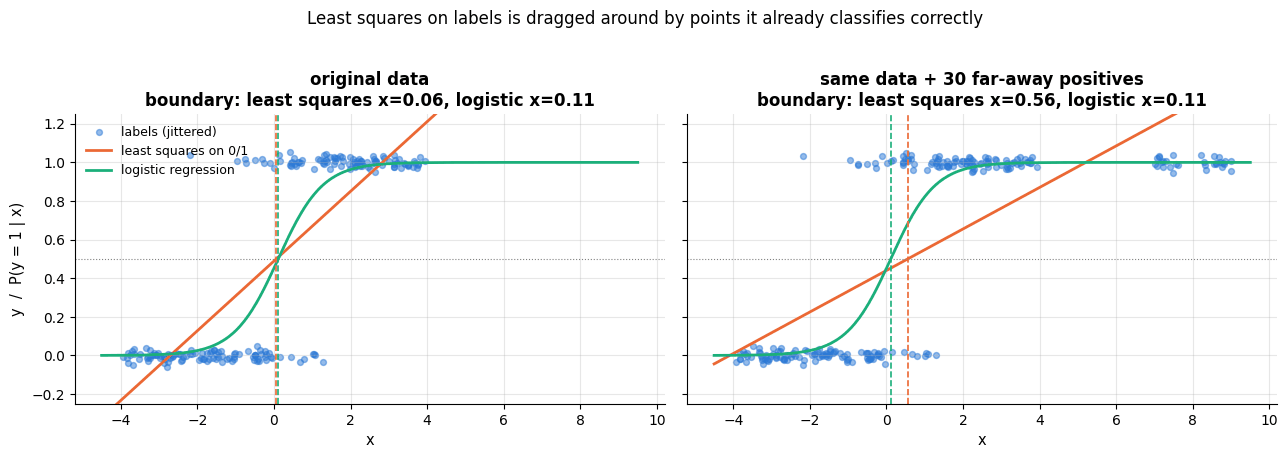

In [2]:
def make_binary_1d(n, slope=1.6, rng=rng):
    """x uniform on [-4, 4]; P(y=1 | x) = sigmoid(slope * x)."""
    x = rng.uniform(-4, 4, n)
    p = 1 / (1 + np.exp(-slope * x))
    y = (rng.random(n) < p).astype(int)
    return x, y

from sklearn.linear_model import LinearRegression, LogisticRegression

x_bin, y_bin = make_binary_1d(200)
x_ext = np.concatenate([x_bin, rng.uniform(7, 9, 30)])          # 30 "easy" positives, far right
y_ext = np.concatenate([y_bin, np.ones(30, dtype=int)])

grid = np.linspace(-4.5, 9.5, 400)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (xx, yy, title) in zip(axes, [(x_bin, y_bin, "original data"),
                                      (x_ext, y_ext, "same data + 30 far-away positives")]):
    ols = LinearRegression().fit(xx[:, None], yy)
    logit = LogisticRegression().fit(xx[:, None], yy)
    ax.scatter(xx, yy + rng.normal(0, 0.02, len(yy)), s=18, alpha=0.5, color=PALETTE[0], label="labels (jittered)")
    ax.plot(grid, ols.predict(grid), color=PALETTE[1], lw=2, label="least squares on 0/1")
    ax.plot(grid, logit.predict_proba(grid)[:, 1], color=PALETTE[2], lw=2, label="logistic regression")
    ax.axhline(0.5, color="gray", lw=0.8, ls=":")
    x_ols = (0.5 - ols.intercept_) / ols.coef_[0]
    x_log = -logit.intercept_[0] / logit.coef_[0, 0]
    ax.axvline(x_ols, color=PALETTE[1], ls="--", lw=1.2)
    ax.axvline(x_log, color=PALETTE[2], ls="--", lw=1.2)
    ax.set_title(f"{title}\nboundary: least squares x={x_ols:.2f}, logistic x={x_log:.2f}")
    ax.set_xlabel("x")
    ax.set_ylim(-0.25, 1.25)
axes[0].set_ylabel("y  /  P(y = 1 | x)")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Least squares on labels is dragged around by points it already classifies correctly", y=1.03)
plt.tight_layout()
plt.show()

The least-squares line leaves the unit interval on both sides, and the extra positives —
which are *not* errors under any threshold — swing its 0.5-crossing to the right. The
logistic fit barely moves: its loss saturates, so a point that is already confidently
correct contributes almost nothing more.

> **Going deeper.** For two classes, least squares on $\{0,1\}$ labels is *linear
> discriminant analysis* in disguise up to a scale factor; the failure above is the
> multi-class "masking" problem in miniature (Hastie et al., 2009, §4.2). The cure is to
> keep the linear function but pass it through a squashing function and change the loss.

### 1.2 Odds, log-odds and the logistic function

Instead of modelling $P(y=1 \mid \mathbf{x})$ directly with a line, model its **log-odds**.
The *odds* of an event with probability $p$ are $p / (1-p)$: "3 to 1" means $p = 0.75$.
Odds live in $(0, \infty)$; their logarithm, the **logit**,

$$
\operatorname{logit}(p) \;=\; \log\frac{p}{1-p},
$$

lives in $(-\infty, \infty)$ — exactly the range of a linear function. So we posit

$$
\log \frac{P(y = 1 \mid \mathbf{x})}{P(y = 0 \mid \mathbf{x})} \;=\; \mathbf{w}^\top\mathbf{x} + b \;=:\; z ,
$$

and invert the logit to recover the probability. The inverse is the **logistic (sigmoid)
function**

$$
\sigma(z) \;=\; \frac{1}{1 + e^{-z}}, \qquad \sigma: \mathbb{R} \to (0,1),
$$

with the two properties we will use constantly:

$$
\sigma(-z) = 1 - \sigma(z), \qquad \sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big).
$$

The derivative identity is what makes the gradient of the loss so simple. Note also that
$\sigma$ is *steepest at $z = 0$* (slope $1/4$) and flattens out in both tails: moving the
score from 3 to 4 changes the probability much less than moving it from 0 to 1.

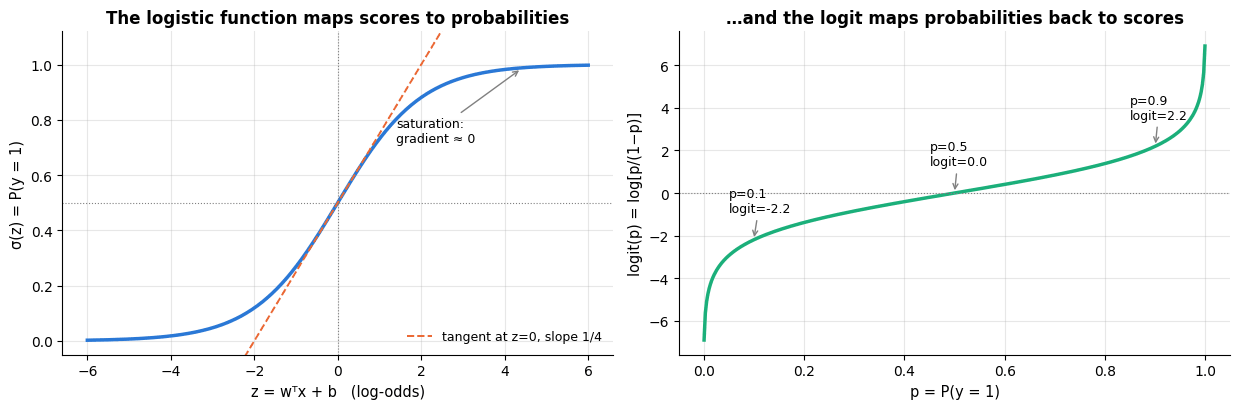

In [3]:
def sigmoid(z):
    """Numerically stable logistic function: no overflow for large |z|."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    e = np.exp(z[~pos])                      # for z < 0 use e^z / (1 + e^z)
    out[~pos] = e / (1.0 + e)
    return out

z_grid = np.linspace(-6, 6, 400)
p_grid = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(z_grid, sigmoid(z_grid), color=PALETTE[0], lw=2.5)
axes[0].axhline(0.5, color="gray", lw=0.8, ls=":")
axes[0].axvline(0, color="gray", lw=0.8, ls=":")
axes[0].plot(z_grid, 0.5 + 0.25 * z_grid, color=PALETTE[1], lw=1.4, ls="--", label="tangent at z=0, slope 1/4")
axes[0].annotate("saturation:\ngradient ≈ 0", xy=(4.4, 0.985), xytext=(1.4, 0.72), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="gray"))
axes[0].set_ylim(-0.05, 1.12)
axes[0].set_xlabel("z = wᵀx + b   (log-odds)")
axes[0].set_ylabel("σ(z) = P(y = 1)")
axes[0].set_title("The logistic function maps scores to probabilities")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].plot(p_grid, np.log(p_grid / (1 - p_grid)), color=PALETTE[2], lw=2.5)
for p_mark in [0.1, 0.5, 0.9]:
    axes[1].annotate(f"p={p_mark}\nlogit={np.log(p_mark/(1-p_mark)):.1f}",
                     xy=(p_mark, np.log(p_mark / (1 - p_mark))), xytext=(p_mark - 0.05, np.log(p_mark/(1-p_mark)) + 1.3),
                     fontsize=9, arrowprops=dict(arrowstyle="->", color="gray"))
axes[1].axhline(0, color="gray", lw=0.8, ls=":")
axes[1].set_xlabel("p = P(y = 1)")
axes[1].set_ylabel("logit(p) = log[p/(1−p)]")
axes[1].set_title("…and the logit maps probabilities back to scores")
plt.tight_layout()
plt.show()

> **Key idea.** Logistic regression is a **linear model of the log-odds**. Everything you
> learned about linear models in notebook 6 — coefficients, scaling, collinearity,
> regularisation — carries over; only the link function and the loss change. In the
> generalised-linear-model table of notebook 6, §9, this is the Bernoulli row with the logit
> link.

### 1.3 The model, and why its decision boundary is a line

Written out, the model is

$$
P(y = 1 \mid \mathbf{x}) \;=\; \sigma(\mathbf{w}^\top\mathbf{x} + b), \qquad
P(y = 0 \mid \mathbf{x}) \;=\; 1 - \sigma(\mathbf{w}^\top\mathbf{x} + b) = \sigma(-(\mathbf{w}^\top\mathbf{x} + b)).
$$

Predicting the more probable class means predicting $1$ whenever $\sigma(z) > 0.5$, i.e.
whenever $z > 0$. The **decision boundary** is therefore the set
$\{\mathbf{x} : \mathbf{w}^\top\mathbf{x} + b = 0\}$ — a hyperplane (a line in 2-D, a plane
in 3-D). Contours of constant probability are hyperplanes *parallel* to it, and $\mathbf{w}$
points in the direction of increasing probability; $\|\mathbf{w}\|$ controls how quickly the
probability changes as we cross the boundary. A large $\|\mathbf{w}\|$ means a sharp,
confident transition, a small one a gentle ramp.

Each coefficient has a clean reading: **increasing $x_j$ by one unit multiplies the odds by
$e^{w_j}$**, holding the other features fixed. That is the odds ratio we use in section 11.

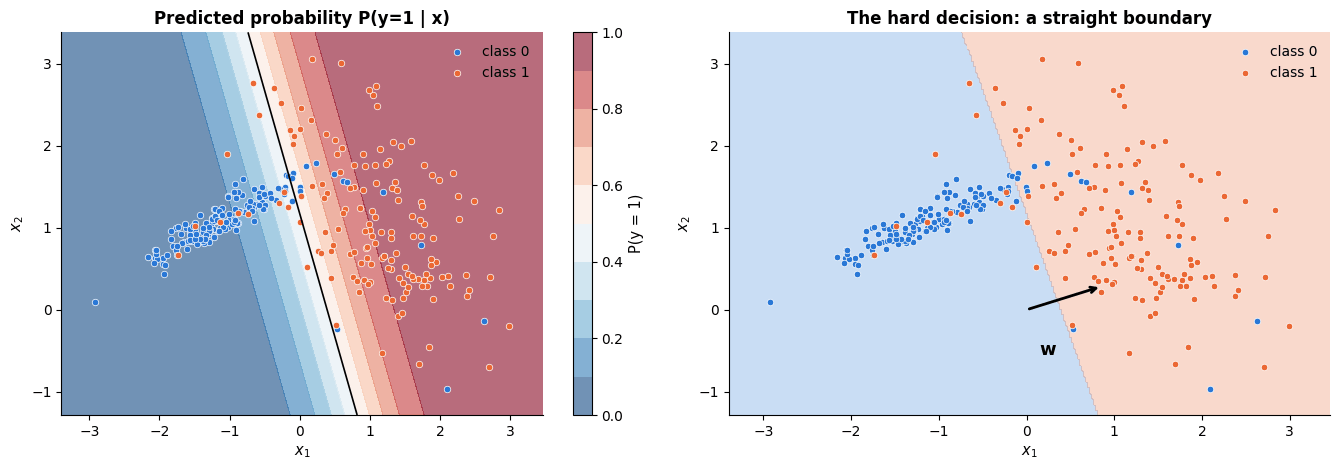

w = [2.3  0.77], b = -0.90   -> odds multiply by 10.00 per unit of x1


In [4]:
from sklearn.datasets import make_classification

X2, y2 = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.1, flip_y=0.06,
                             random_state=RANDOM_STATE)
clf2 = LogisticRegression().fit(X2, y2)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
plot_decision_boundary(clf2, X2, y2, ax=axes[0], proba=True,
                       title="Predicted probability P(y=1 | x)", feature_names=("$x_1$", "$x_2$"))
plot_decision_boundary(clf2, X2, y2, ax=axes[1],
                       title="The hard decision: a straight boundary", feature_names=("$x_1$", "$x_2$"))
w, b = clf2.coef_[0], clf2.intercept_[0]
axes[1].annotate("", xy=(0.9 * w[0] / np.linalg.norm(w), 0.9 * w[1] / np.linalg.norm(w)),
                 xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="black", lw=2))
axes[1].text(0.15, -0.55, "w", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"w = {w.round(2)}, b = {b:.2f}   -> odds multiply by {np.exp(w[0]):.2f} per unit of x1")

The left panel shows the probability field: parallel bands, steepest across the boundary.
The right panel shows the hard prediction and the weight vector $\mathbf{w}$, orthogonal to
the boundary.

## 2. Maximum likelihood, the cross-entropy loss, and how to minimise it

### 2.1 From likelihood to loss

Each observation is a Bernoulli trial with success probability $p_i = \sigma(z_i)$,
$z_i = \mathbf{w}^\top\mathbf{x}_i + b$. Assuming the $n$ observations are independent given
the features, the likelihood of the parameters is

$$
L(\mathbf{w}, b) \;=\; \prod_{i=1}^n p_i^{\,y_i}\,(1-p_i)^{\,1-y_i}.
$$

Taking $-\frac{1}{n}\log$ turns the product into an average and the maximisation into a
minimisation. The result is the **binary cross-entropy** (or **log loss**):

$$
\mathcal{L}(\mathbf{w}, b) \;=\; -\frac{1}{n}\sum_{i=1}^n \Big[\, y_i \log p_i + (1-y_i)\log(1-p_i) \Big].
$$

Substituting $p_i = \sigma(z_i)$ and using $\log \sigma(z) = -\log(1+e^{-z})$ gives the form
we actually compute with, which never overflows:

$$
\mathcal{L} \;=\; \frac{1}{n}\sum_{i=1}^n \Big[\log\big(1 + e^{z_i}\big) - y_i z_i\Big]
\;=\; \frac{1}{n}\sum_{i=1}^n \Big[\operatorname{logaddexp}(0, z_i) - y_i z_i\Big].
$$

Per-sample, the loss is $-\log(\text{probability assigned to the true class})$: it is $0$
for a perfect confident prediction and $\to \infty$ for a confident mistake. **Log loss is
unbounded**, which is why a single over-confident error can dominate it — a fact we return
to in section 7.

### 2.2 The gradient, the Hessian and convexity

Differentiate. With $\sigma'(z) = \sigma(z)(1-\sigma(z))$, the chain rule collapses
beautifully:

$$
\frac{\partial \mathcal{L}}{\partial z_i} = \frac{1}{n}\big(p_i - y_i\big)
\quad\Longrightarrow\quad
\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{n}\,\mathbf{X}^\top(\mathbf{p} - \mathbf{y}),
\qquad
\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n}\sum_i (p_i - y_i).
$$

This is *exactly* the gradient of least squares with the residual $\mathbf{p} - \mathbf{y}$
in place of $\hat{\mathbf{y}} - \mathbf{y}$ — a general property of generalised linear
models with the canonical link (notebook 6, §9). Unlike least squares, however, there is no
closed-form solution: setting the gradient to zero gives $d+1$ transcendental equations.

The Hessian is

$$
\nabla^2_{\mathbf{w}} \mathcal{L} \;=\; \frac{1}{n}\,\mathbf{X}^\top \mathbf{S}\,\mathbf{X},
\qquad \mathbf{S} = \operatorname{diag}\big(p_i(1-p_i)\big) \succeq 0 .
$$

Because $\mathbf{S}$ has non-negative entries, $\mathbf{v}^\top \mathbf{X}^\top\mathbf{S}\mathbf{X}\mathbf{v} = \sum_i p_i(1-p_i)(\mathbf{x}_i^\top\mathbf{v})^2 \ge 0$
for every $\mathbf{v}$: the Hessian is positive semi-definite, so

> **Key idea.** The logistic loss is **convex**. Every local minimum is global, and any
> sensible optimiser finds the same answer — no restarts, no random initialisation to worry
> about. (It is *strictly* convex once an $\ell_2$ penalty is added; without one the minimum
> may be at infinity — see section 9.2.)

Let us look at the loss surface and watch three optimisers walk down it. We use two features
and no intercept so that the whole objective fits on a page.

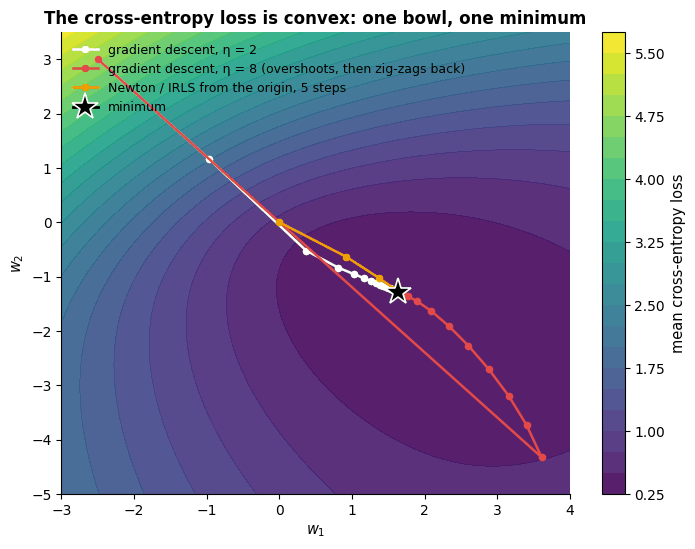

minimum at w = [ 1.639 -1.282], loss = 0.2890


In [5]:
X_surf, y_surf = make_classification(n_samples=200, n_features=2, n_redundant=0, n_informative=2,
                                     n_clusters_per_class=1, class_sep=0.9, flip_y=0.10, random_state=7)
X_surf = X_surf - X_surf.mean(axis=0)                    # centred: the intercept is ~0

def loss_no_intercept(w, X=X_surf, y=y_surf):
    z = X @ np.atleast_1d(w)
    return np.mean(np.logaddexp(0.0, z) - y * z)

w1 = np.linspace(-3.0, 4.0, 150)
w2 = np.linspace(-5.0, 3.5, 150)
W1, W2 = np.meshgrid(w1, w2)
Z = np.array([[loss_no_intercept(np.array([a, b_])) for a in w1] for b_ in w2])

def gd_path(lr, n_steps, start=(-2.5, 3.0)):
    w, path = np.array(start, dtype=float), [np.array(start, dtype=float)]
    for _ in range(n_steps):
        p = sigmoid(X_surf @ w)
        w = w - lr * (X_surf.T @ (p - y_surf) / len(y_surf))
        path.append(w.copy())
    return np.array(path)

def newton_path(n_steps, start=(0.0, 0.0)):
    w, path = np.array(start, dtype=float), [np.array(start, dtype=float)]
    for _ in range(n_steps):
        p = sigmoid(X_surf @ w)
        g = X_surf.T @ (p - y_surf) / len(y_surf)
        H = X_surf.T @ (X_surf * (p * (1 - p))[:, None]) / len(y_surf) + 1e-8 * np.eye(2)
        w = w - np.linalg.solve(H, g)
        path.append(w.copy())
    return np.array(path)

fig, ax = plt.subplots(figsize=(8.2, 6))
cs = ax.contourf(W1, W2, Z, levels=25, cmap="viridis", alpha=0.9)
plt.colorbar(cs, ax=ax, label="mean cross-entropy loss")
for path, name, colour in [(gd_path(2.0, 60), "gradient descent, η = 2", "white"),
                           (gd_path(8.0, 60), "gradient descent, η = 8 (overshoots, then zig-zags back)", PALETTE[7]),
                           (newton_path(5), "Newton / IRLS from the origin, 5 steps", PALETTE[3])]:
    ax.plot(path[:, 0], path[:, 1], "-o", ms=4.5, lw=1.8, color=colour, label=name)
w_opt = gd_path(2.0, 4000)[-1]
ax.plot(w_opt[0], w_opt[1], marker="*", ms=20, color="black", mec="white", mew=1.2, label="minimum")
ax.set_xlim(w1.min(), w1.max())
ax.set_ylim(w2.min(), w2.max())
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title("The cross-entropy loss is convex: one bowl, one minimum")
ax.legend(loc="upper left", fontsize=9)
ax.grid(False)
plt.show()
print(f"minimum at w = {w_opt.round(3)}, loss = {loss_no_intercept(w_opt):.4f}")

The contours form a single bowl. Gradient descent with a sensible step size walks straight
in; with too large a step it zig-zags across the valley (and with an even larger one it
would leave the picture entirely); Newton's method, which uses the curvature, is there in a
handful of steps.

> **Warning.** Newton's method is started at the origin here on purpose. Far from the
> optimum most $p_i(1-p_i)$ are nearly zero, the Hessian is close to singular, and the full
> Newton step can overshoot spectacularly — the method is only *locally* convergent.
> Production solvers damp it with a line search or a trust region; `lbfgs` and `newton-cg`
> both do.

### 2.3 Gradient descent from scratch

The algorithm, in full:

1. Initialise $\mathbf{w} = \mathbf{0}$, $b = 0$.
2. Repeat: compute $\mathbf{p} = \sigma(\mathbf{X}\mathbf{w} + b)$, the residual
   $\mathbf{r} = \mathbf{p} - \mathbf{y}$, then
   $\mathbf{w} \leftarrow \mathbf{w} - \eta\big(\tfrac{1}{n}\mathbf{X}^\top\mathbf{r} + \lambda\mathbf{w}\big)$
   and $b \leftarrow b - \eta\,\bar{r}$.
3. Stop when the gradient norm (or the change in loss) is below a tolerance.

The optional $\lambda \|\mathbf{w}\|_2^2 / 2$ term is the $\ell_2$ penalty of section 3;
the intercept is deliberately left unpenalised.

In [6]:
def logistic_loss(X, y, w, b, lam=0.0):
    """Mean cross-entropy plus an L2 penalty on w (the intercept is not penalised)."""
    z = X @ w + b
    return float(np.mean(np.logaddexp(0.0, z) - y * z) + 0.5 * lam * w @ w)

def fit_logistic_gd(X, y, lam=0.0, lr=1.0, n_iter=2000, tol=1e-9):
    """Batch gradient descent for binary logistic regression. Returns w, b, loss history."""
    n, d = X.shape
    w, b = np.zeros(d), 0.0
    history = []
    for _ in range(n_iter):
        p = sigmoid(X @ w + b)
        r = p - y                                     # the residual, exactly as in linear regression
        w -= lr * (X.T @ r / n + lam * w)
        b -= lr * r.mean()
        history.append(logistic_loss(X, y, w, b, lam))
        if len(history) > 1 and abs(history[-2] - history[-1]) < tol:
            break
    return w, b, np.array(history)

Feature scaling matters here exactly as it did in notebook 6, §2.3: the largest usable step
size is set by the largest curvature, i.e. by the largest eigenvalue of
$\mathbf{X}^\top\mathbf{S}\mathbf{X}/n$. Badly scaled features make that eigenvalue enormous
and force a tiny $\eta$.

condition number: raw 1.5e+06   standardised 3.2e+02


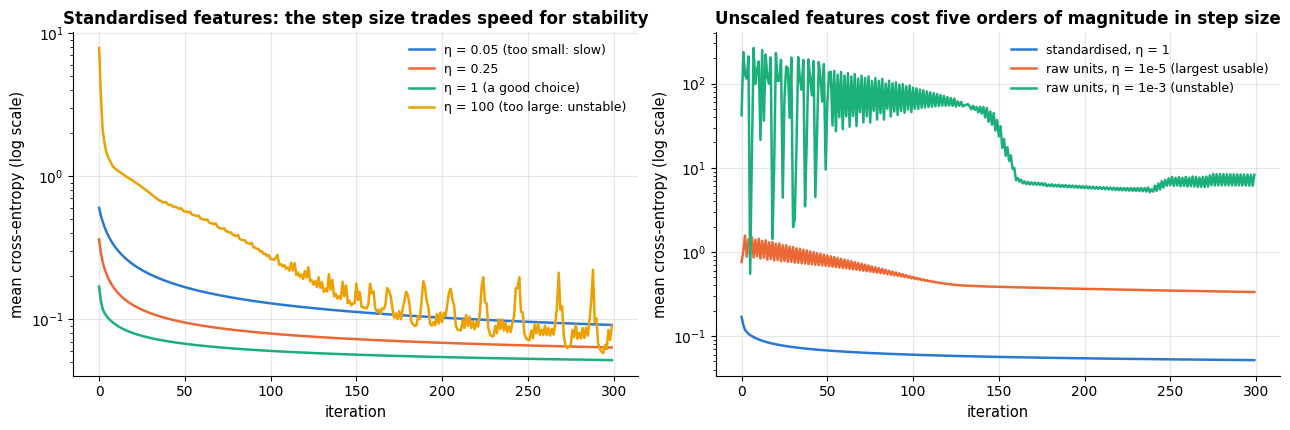

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
X_raw, y_bc = cancer.data, cancer.target
X_std = StandardScaler().fit_transform(X_raw)
print(f"condition number: raw {np.linalg.cond(X_raw):.1e}   standardised {np.linalg.cond(X_std):.1e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for lr, note in [(0.05, "too small: slow"), (0.25, ""), (1.0, "a good choice"), (100.0, "too large: unstable")]:
    _, _, hist = fit_logistic_gd(X_std, y_bc, lr=lr, n_iter=300, tol=0.0)
    axes[0].plot(hist, lw=1.8, label=f"η = {lr:g}" + (f" ({note})" if note else ""))
axes[0].set_yscale("log")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("mean cross-entropy (log scale)")
axes[0].set_title("Standardised features: the step size trades speed for stability")
axes[0].legend(fontsize=9)

for X_used, lr, name in [(X_std, 1.0, "standardised, η = 1"),
                         (X_raw, 1e-5, "raw units, η = 1e-5 (largest usable)"),
                         (X_raw, 1e-3, "raw units, η = 1e-3 (unstable)")]:
    _, _, hist = fit_logistic_gd(X_used, y_bc, lr=lr, n_iter=300, tol=0.0)
    axes[1].plot(hist, lw=1.8, label=name)
axes[1].set_yscale("log")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("mean cross-entropy (log scale)")
axes[1].set_title("Unscaled features cost five orders of magnitude in step size")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### 2.4 Newton's method, a.k.a. IRLS

Gradient descent uses only the slope. **Newton's method** uses the curvature too: it
minimises the local quadratic approximation of the loss, giving the update

$$
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \big(\nabla^2\mathcal{L}\big)^{-1}\nabla\mathcal{L}
\;=\; \boldsymbol{\theta} + \big(\mathbf{X}^\top\mathbf{S}\mathbf{X}\big)^{-1}\mathbf{X}^\top(\mathbf{y} - \mathbf{p}).
$$

Rewriting it shows why statisticians call it **iteratively reweighted least squares**: each
step is a weighted least-squares fit of the *working response*
$\tilde{y}_i = z_i + (y_i - p_i)/[p_i(1-p_i)]$ with weights $p_i(1-p_i)$. This is how
`glm` in R and `statsmodels`' `Logit` fit the model. The price is the $O(nd^2 + d^3)$ cost
of forming and solving the Hessian each step, which is why scikit-learn's default solver
(`lbfgs`) uses a *low-rank approximation* of the inverse Hessian instead.

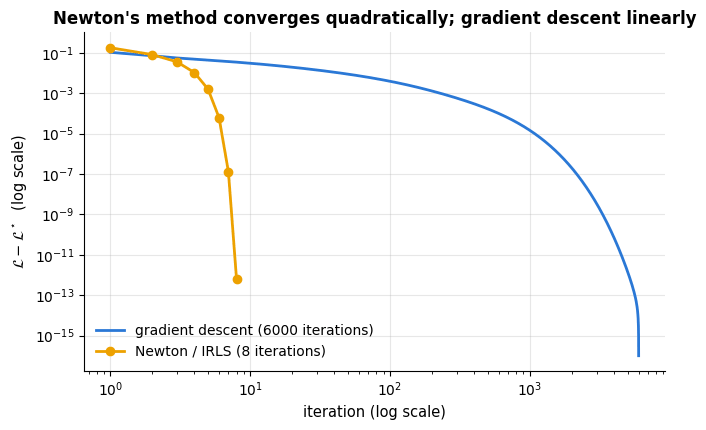

In [8]:
def fit_logistic_newton(X, y, lam=0.0, n_iter=8):
    """Newton / IRLS for binary logistic regression (intercept appended as a column of ones)."""
    n, d = X.shape
    Xb = np.hstack([X, np.ones((n, 1))])
    theta = np.zeros(d + 1)
    penalty = lam * np.eye(d + 1)
    penalty[-1, -1] = 0.0                                   # do not penalise the intercept
    history = []
    for _ in range(n_iter):
        p = sigmoid(Xb @ theta)
        grad = Xb.T @ (p - y) / n + penalty @ theta
        S = p * (1 - p)
        H = Xb.T @ (Xb * S[:, None]) / n + penalty + 1e-9 * np.eye(d + 1)
        theta -= np.linalg.solve(H, grad)
        history.append(logistic_loss(X, y, theta[:-1], theta[-1], lam))
    return theta[:-1], theta[-1], np.array(history)

lam_bc = 1.0 / (len(y_bc) * 1.0)                            # equivalent to scikit-learn's C = 1 (section 3.1)
w_gd, b_gd, hist_gd = fit_logistic_gd(X_std, y_bc, lam=lam_bc, lr=1.0, n_iter=6000, tol=0.0)
w_nt, b_nt, hist_nt = fit_logistic_newton(X_std, y_bc, lam=lam_bc, n_iter=8)
l_star = min(hist_gd[-1], hist_nt[-1])

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(np.arange(1, len(hist_gd) + 1), hist_gd - l_star + 1e-16, color=PALETTE[0], lw=2,
        label=f"gradient descent ({len(hist_gd)} iterations)")
ax.plot(np.arange(1, len(hist_nt) + 1), hist_nt - l_star + 1e-16, "-o", color=PALETTE[3], lw=2,
        label=f"Newton / IRLS ({len(hist_nt)} iterations)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("iteration (log scale)")
ax.set_ylabel(r"$\mathcal{L} - \mathcal{L}^\star$  (log scale)")
ax.set_title("Newton's method converges quadratically; gradient descent linearly")
ax.legend()
plt.show()

The Newton curve drops by several orders of magnitude *per step* near the optimum
(quadratic convergence), whereas gradient descent needs thousands of iterations to reach the
same accuracy. For $d$ in the hundreds, use a second-order method; for $d$ in the millions,
use first-order methods or `saga`.

### 2.5 Checking against scikit-learn

scikit-learn minimises a slightly different but equivalent objective — the *sum* of the
losses times $C$, plus $\tfrac12\|\mathbf{w}\|^2$ — so our $\lambda$ and its $C$ are related
by $\lambda = 1/(nC)$. With that mapping, all three implementations must agree.

In [9]:
sk_lr = LogisticRegression(C=1.0, max_iter=5000, tol=1e-10).fit(X_std, y_bc)
print(f"gradient descent vs scikit-learn : max |Δw| = {np.abs(w_gd - sk_lr.coef_[0]).max():.2e}, "
      f"|Δb| = {abs(b_gd - sk_lr.intercept_[0]):.2e}")
print(f"Newton / IRLS    vs scikit-learn : max |Δw| = {np.abs(w_nt - sk_lr.coef_[0]).max():.2e}, "
      f"|Δb| = {abs(b_nt - sk_lr.intercept_[0]):.2e}")
print(f"loss  ours {logistic_loss(X_std, y_bc, w_nt, b_nt, lam_bc):.10f}   "
      f"scikit-learn {logistic_loss(X_std, y_bc, sk_lr.coef_[0], sk_lr.intercept_[0], lam_bc):.10f}")

gradient descent vs scikit-learn : max |Δw| = 1.94e-06, |Δb| = 2.79e-07
Newton / IRLS    vs scikit-learn : max |Δw| = 3.53e-06, |Δb| = 1.97e-07
loss  ours 0.0663601862   scikit-learn 0.0663601862


Agreement to six decimal places: the library is doing exactly what the mathematics above
says, only faster and with better stopping rules.

## 3. Regularisation, penalties and solvers

### 3.1 The penalised objective and the parameter `C`

Because the loss is unbounded below in $\|\mathbf{w}\|$ when the classes are separable
(section 9.2), and because $d$ is often comparable to $n$, **logistic regression is
essentially always regularised**. scikit-learn minimises

$$
\underbrace{\tfrac{1-\rho}{2}\,\|\mathbf{w}\|_2^2 \;+\; \rho\,\|\mathbf{w}\|_1}_{\text{penalty}}
\;+\; C\sum_{i=1}^n \ell\big(y_i, \mathbf{w}^\top\mathbf{x}_i + b\big),
$$

where $\rho$ is `l1_ratio` and $C > 0$ is the inverse regularisation strength
($C = 1/\lambda$ in the notation of notebook 6). **Small `C` = strong regularisation =
simpler model.** The default is `C=1.0` with `l1_ratio=0.0` (pure $\ell_2$).

> **Warning.** The penalty acts on the raw coefficients, so it is only meaningful if the
> features are on comparable scales. **Always standardise inside a pipeline** before a
> penalised logistic regression, exactly as for ridge and lasso (notebook 6, §7).

> **Note on the API — read this if your scikit-learn is older than 1.8.** Version 1.8
> deprecated the `penalty=` argument in favour of `l1_ratio`: `l1_ratio=0` is $\ell_2$,
> `l1_ratio=1` is $\ell_1$, anything strictly between is elastic net, and `C=np.inf` means no
> penalty at all. This notebook uses the new spelling throughout. On **scikit-learn ≤ 1.7**
> `l1_ratio` is read *only* when `penalty="elasticnet"`, so `LogisticRegression(l1_ratio=1)`
> would silently fit an $\ell_2$ model — a trap worth knowing about. The translation is
> mechanical:
>
> ```py
> LogisticRegression(l1_ratio=0)           # <= 1.7:  LogisticRegression(penalty="l2")
> LogisticRegression(l1_ratio=1, solver="saga")    # penalty="l1"
> LogisticRegression(l1_ratio=0.5, solver="saga")  # penalty="elasticnet", l1_ratio=0.5
> LogisticRegression(C=np.inf)             # <= 1.7:  LogisticRegression(penalty=None)
> ```

### 3.2 Coefficient paths: $\ell_2$, $\ell_1$ and elastic net

The three penalties do to logistic regression exactly what ridge, lasso and elastic net do
to linear regression (notebook 6, §7): $\ell_2$ shrinks all coefficients smoothly towards
zero, $\ell_1$ sets some of them exactly to zero (feature selection), and elastic net
interpolates while keeping groups of correlated features together. The **coefficient path**
— every coefficient as a function of $C$ — is the picture to have in mind.

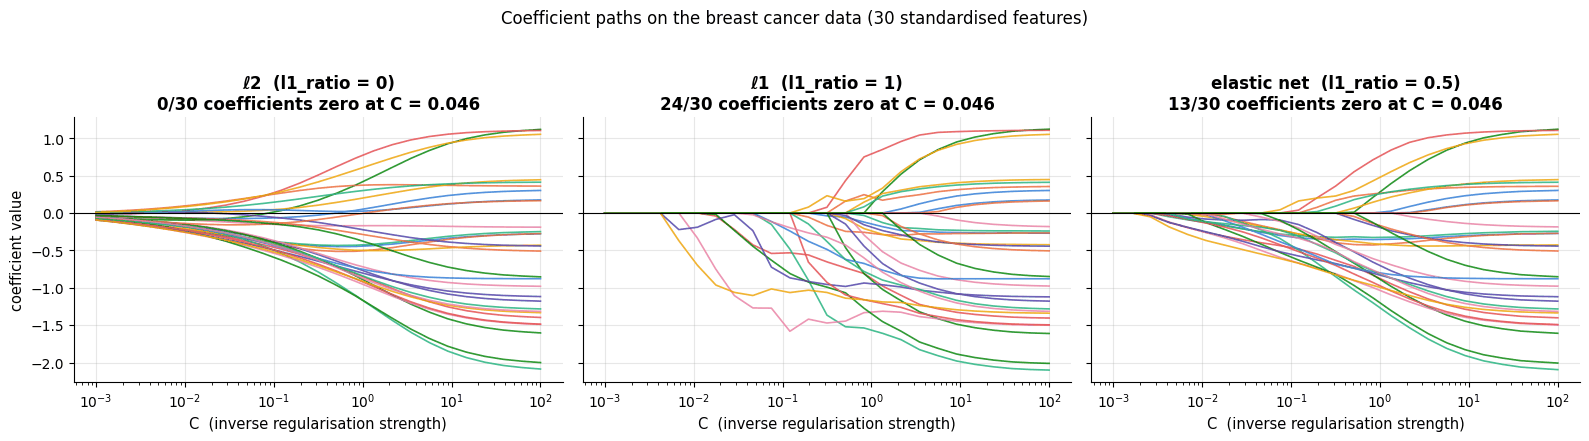

In [10]:
from sklearn.pipeline import make_pipeline

Cs_path = np.logspace(-3, 2, 25)
paths = {}
for ratio, label in [(0.0, "ℓ2  (l1_ratio = 0)"), (1.0, "ℓ1  (l1_ratio = 1)"), (0.5, "elastic net  (l1_ratio = 0.5)")]:
    coefs = []
    for C in Cs_path:
        m = make_pipeline(StandardScaler(),
                          LogisticRegression(C=C, l1_ratio=ratio, solver="saga", tol=1e-3,
                                             max_iter=10000, random_state=RANDOM_STATE)).fit(X_raw, y_bc)
        coefs.append(m[-1].coef_[0])
    paths[label] = np.array(coefs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (label, coefs) in zip(axes, paths.items()):
    for j in range(coefs.shape[1]):
        ax.plot(Cs_path, coefs[:, j], lw=1.2, alpha=0.8)
    ax.set_xscale("log")
    ax.axhline(0, color="black", lw=0.8)
    n_zero = (np.abs(coefs[len(Cs_path) // 3]) < 1e-6).sum()
    ax.set_title(f"{label}\n{n_zero}/{coefs.shape[1]} coefficients zero at C = {Cs_path[len(Cs_path)//3]:.3f}")
    ax.set_xlabel("C  (inverse regularisation strength)")
axes[0].set_ylabel("coefficient value")
fig.suptitle("Coefficient paths on the breast cancer data (30 standardised features)", y=1.04)
plt.tight_layout()
plt.show()

Reading the paths right to left (from weak to strong regularisation): under $\ell_2$ every
coefficient decays smoothly and none is ever exactly zero; under $\ell_1$ coefficients hit
zero one after another and stay there, so the path doubles as a feature-selection ranking;
elastic net behaves like $\ell_1$ but drops correlated features more gently.

### 3.3 Which solver?

The solver only affects *how* the (unique) optimum is reached, not *what* it is — but it
decides which penalties you may use and how long you wait.

| Solver | Penalties | Multi-class | Notes |
|---|---|---|---|
| `lbfgs` (default) | $\ell_2$, none | multinomial | quasi-Newton; robust, good default up to ~$10^4$ features |
| `newton-cholesky` | $\ell_2$, none | multinomial | exact Newton; excellent when $n \gg d$ and $d$ is small |
| `liblinear` | $\ell_1$, $\ell_2$ | one-vs-rest only | coordinate descent; fast on small, sparse problems |
| `saga` | $\ell_1$, $\ell_2$, elastic net, none | multinomial | variance-reduced SGD; the only elastic-net option; scales to large $n$ |
| `sag` | $\ell_2$, none | multinomial | predecessor of `saga`; needs scaled features |
| `newton-cg` | $\ell_2$, none | multinomial | truncated Newton; rarely the best choice today |

A practical rule: **start with `lbfgs`; switch to `saga` when you want $\ell_1$ or elastic
net or when $n$ is large; use `liblinear` for small sparse text problems** (notebook 15).
Section 10.5 measures the trade-off.

## 4. More than two classes: softmax and one-vs-rest

### 4.1 The multinomial (softmax) model

With $K$ classes, give each class its own weight vector $\mathbf{w}_k$ and bias $b_k$, and
normalise the exponentiated scores:

$$
P(y = k \mid \mathbf{x}) \;=\; \frac{\exp(\mathbf{w}_k^\top\mathbf{x} + b_k)}{\sum_{m=1}^K \exp(\mathbf{w}_m^\top\mathbf{x} + b_m)} \;=:\; p_k(\mathbf{x}).
$$

This is the **softmax** function; for $K=2$ it reduces to the sigmoid of the *difference*
of the two scores, so the binary model is a special case. The loss is the multi-class
cross-entropy, with $y_{ik} = 1$ if sample $i$ belongs to class $k$ and $0$ otherwise:

$$
\mathcal{L}(\mathbf{W}, \mathbf{b}) \;=\; -\frac{1}{n}\sum_{i=1}^n\sum_{k=1}^K y_{ik}\log p_k(\mathbf{x}_i),
\qquad
\nabla_{\mathbf{W}} \mathcal{L} = \frac{1}{n}\,\mathbf{X}^\top(\mathbf{P} - \mathbf{Y}),
$$

where $\mathbf{P}, \mathbf{Y} \in \mathbb{R}^{n\times K}$ hold the predicted and one-hot
true probabilities. The gradient has the *same* "design matrix times residual" shape as in
the binary case — one of the reasons this model generalises so cleanly.

The alternative is **one-vs-rest (OvR)**: fit $K$ independent binary classifiers, each
separating one class from all the others, and predict the class with the largest score.
OvR is simpler and embarrassingly parallel, but its $K$ scores are not calibrated against
each other, so the probabilities must be renormalised by hand and regions of the input
space can end up claimed by no classifier or by several.

### 4.2 Softmax regression from scratch, checked against scikit-learn

In [11]:
from sklearn.datasets import load_iris

def softmax(Z):
    """Row-wise softmax, shifted for numerical stability."""
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def fit_softmax_gd(X, y, n_classes, lam=0.0, lr=0.5, n_iter=4000):
    n, d = X.shape
    Y = np.eye(n_classes)[y]                                 # one-hot targets
    W, b = np.zeros((d, n_classes)), np.zeros(n_classes)
    history = []
    for _ in range(n_iter):
        P = softmax(X @ W + b)
        R = (P - Y) / n                                      # the residual again
        W -= lr * (X.T @ R + lam * W)
        b -= lr * R.sum(axis=0)
        history.append(-np.mean(np.log(np.clip(P[np.arange(n), y], 1e-12, None))) + 0.5 * lam * np.sum(W * W))
    return W, b, np.array(history)

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target
lam_iris = 1.0 / (len(y_iris) * 1.0)                         # matches C = 1
W_s, b_s, hist_s = fit_softmax_gd(X_iris, y_iris, 3, lam=lam_iris, lr=0.5, n_iter=8000)
sk_soft = LogisticRegression(C=1.0, max_iter=5000, tol=1e-10).fit(X_iris, y_iris)

P_ours = softmax(X_iris @ W_s + b_s)
P_sk = sk_soft.predict_proba(X_iris)
print(f"max |Δ predicted probability| = {np.abs(P_ours - P_sk).max():.2e}")
print(f"max |Δ coefficient|           = {np.abs(W_s.T - sk_soft.coef_).max():.2e}")
print(f"training accuracy: ours {(P_ours.argmax(1) == y_iris).mean():.4f}, "
      f"scikit-learn {sk_soft.score(X_iris, y_iris):.4f}")

max |Δ predicted probability| = 7.72e-08
max |Δ coefficient|           = 2.99e-07
training accuracy: ours 0.9733, scikit-learn 0.9733


### 4.3 One-vs-rest versus multinomial

`LogisticRegression` fits the multinomial model for $K \ge 3$ (recent scikit-learn versions
removed the old `multi_class` switch); wrap it in `OneVsRestClassifier` to get the OvR
behaviour. On two iris features the two reach the same training accuracy, but the boundaries
sit at visibly different angles: OvR fits each line against a different "rest" and the three
lines meet wherever they happen to, while the softmax model balances all three scores at
once.

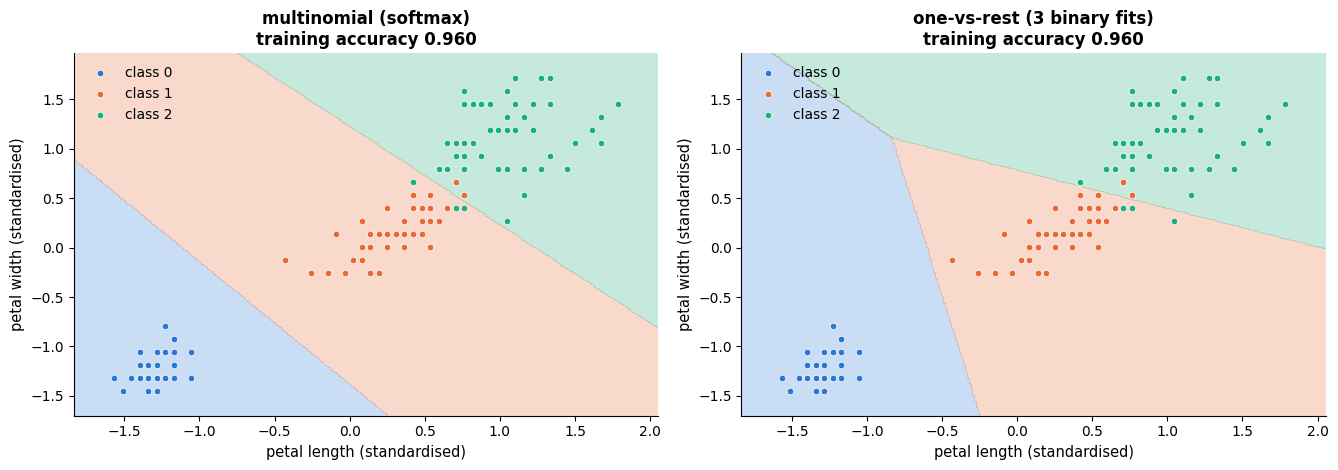

In [12]:
from sklearn.multiclass import OneVsRestClassifier

X_iris2 = X_iris[:, [2, 3]]                                   # petal length and width
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for ax, (name, model) in zip(axes, [
        ("multinomial (softmax)", LogisticRegression(C=10.0, max_iter=2000)),
        ("one-vs-rest (3 binary fits)", OneVsRestClassifier(LogisticRegression(C=10.0, max_iter=2000)))]):
    model.fit(X_iris2, y_iris)
    plot_decision_boundary(model, X_iris2, y_iris, ax=ax,
                           title=f"{name}\ntraining accuracy {model.score(X_iris2, y_iris):.3f}",
                           feature_names=("petal length (standardised)", "petal width (standardised)"))
plt.tight_layout()
plt.show()

In practice the two rarely differ much in accuracy; the multinomial fit gives coherent
probabilities across classes and is the better default. OvR remains useful when you need
$K$ independent, individually thresholdable scores — for example in multi-label problems.

### 4.4 Ten classes: handwritten digits

test accuracy: 0.970


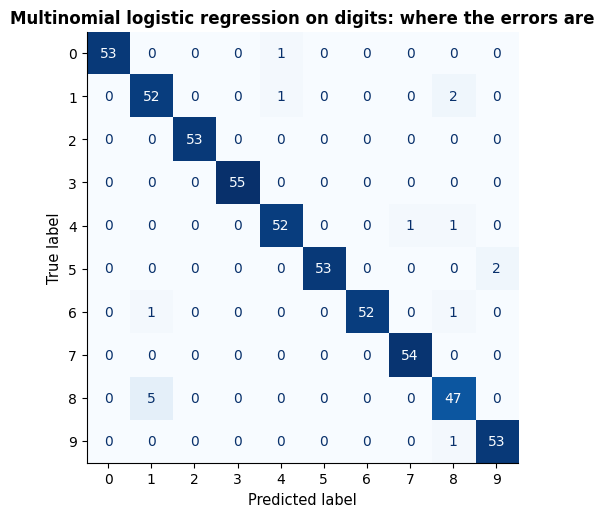

In [13]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

digits = load_digits()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.3,
                                              stratify=digits.target, random_state=RANDOM_STATE)
digit_clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=2000,
                                                               random_state=RANDOM_STATE)).fit(Xd_tr, yd_tr)
print(f"test accuracy: {digit_clf.score(Xd_te, yd_te):.3f}")

fig, ax = plt.subplots(figsize=(6.4, 5.6))
ConfusionMatrixDisplay.from_estimator(digit_clf, Xd_te, yd_te, cmap="Blues", colorbar=False,
                                      ax=ax, values_format="d")
ax.set_title("Multinomial logistic regression on digits: where the errors are")
ax.grid(False)
plt.show()

A 64-dimensional linear model classifies handwritten digits with about 97 % accuracy. The
confusion matrix shows that the errors are not spread evenly: they concentrate on the
digit pairs whose pixel patterns overlap — 8 mistaken for 1 most often of all. That
structure is invisible in the accuracy number — which brings us to metrics.

## 5. The confusion matrix and everything built on it

### 5.1 The running example: a churn model

We need a classifier with interesting errors. The bundled `load_churn()` data (5 000
customers, 33 % churn) is **simulated** — the generating process is known, which makes it
an excellent teaching set, but it is not a substitute for a real-data case study; section 11
supplies that with the breast cancer data. The preprocessing follows notebook 4: median
imputation and standardisation for the numeric columns, one-hot encoding for the
categorical ones, all inside a `Pipeline` so that nothing leaks (notebook 5, §7.1).

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

churn = load_churn()
num_cols = ["tenure_months", "monthly_charges", "total_charges", "support_tickets",
            "senior_citizen", "has_partner", "tech_support", "streaming"]
cat_cols = ["region", "contract", "payment_method", "internet_service"]
X_ch, y_ch = churn[num_cols + cat_cols], churn["churned"].to_numpy()

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
])
churn_clf = Pipeline([("prep", preprocess),
                      ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])

X_ch_tr, X_ch_te, y_ch_tr, y_ch_te = train_test_split(X_ch, y_ch, test_size=0.25, stratify=y_ch,
                                                      random_state=RANDOM_STATE)
churn_clf.fit(X_ch_tr, y_ch_tr)
proba_ch = churn_clf.predict_proba(X_ch_te)[:, 1]
print(f"{len(y_ch)} customers, churn rate {y_ch.mean():.1%}")
print(f"test accuracy {churn_clf.score(X_ch_te, y_ch_te):.3f}")

5000 customers, churn rate 32.6%
test accuracy 0.781


### 5.2 The confusion matrix

Every hard prediction falls into one of four boxes. With the **positive class** = "churns"
(scikit-learn always treats the larger label, here `1`, as positive unless told otherwise):

| | predicted 0 | predicted 1 |
|---|---|---|
| **actual 0** | true negative (TN) | false positive (FP) — *type I error* |
| **actual 1** | false negative (FN) — *type II error* | true positive (TP) |

`confusion_matrix` returns exactly this layout, `[[TN, FP], [FN, TP]]`. Everything in this
section is a function of those four numbers, so it is worth staring at the matrix before
computing anything else.

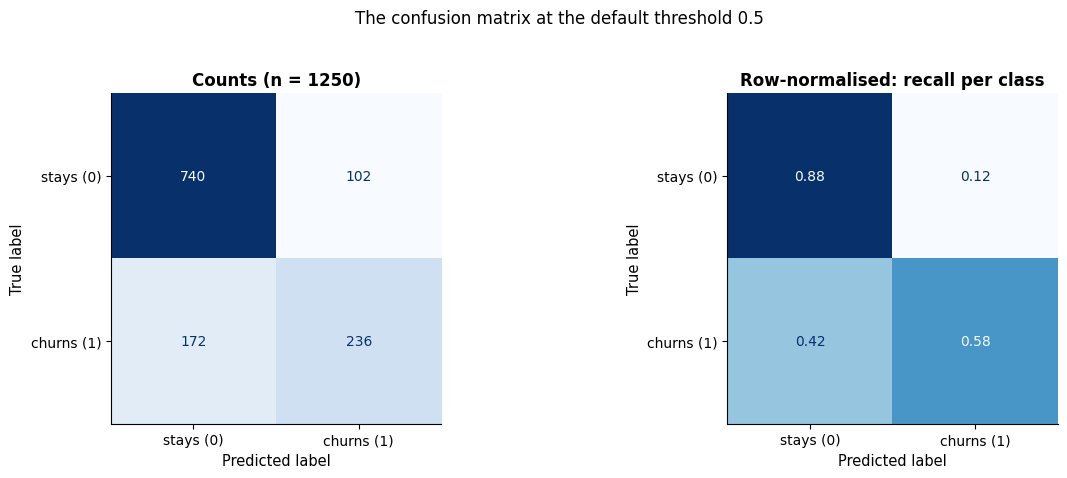

TN=740  FP=102  FN=172  TP=236


In [15]:
from sklearn.metrics import confusion_matrix

y_pred_ch = churn_clf.predict(X_ch_te)
cm = confusion_matrix(y_ch_te, y_pred_ch)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ConfusionMatrixDisplay(cm, display_labels=["stays (0)", "churns (1)"]).plot(
    cmap="Blues", ax=axes[0], colorbar=False, values_format="d")
axes[0].set_title(f"Counts (n = {len(y_ch_te)})")
axes[0].grid(False)
ConfusionMatrixDisplay(confusion_matrix(y_ch_te, y_pred_ch, normalize="true"),
                       display_labels=["stays (0)", "churns (1)"]).plot(
    cmap="Blues", ax=axes[1], colorbar=False, values_format=".2f")
axes[1].set_title("Row-normalised: recall per class")
axes[1].grid(False)
fig.suptitle("The confusion matrix at the default threshold 0.5", y=1.03)
plt.tight_layout()
plt.show()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

Normalising by row (`normalize="true"`) gives the **recall of each class** and is usually
the most informative view; normalising by column gives the precision of each class.

### 5.3 Accuracy, and how it lies

$$
\text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

is the fraction of correct predictions. It is the right metric when the classes are roughly
balanced *and* the two kinds of error cost the same — a combination that is rarer than it
sounds. Make the positive class rare and accuracy becomes uninformative: predicting "never
churns" scores 97 % on a 3 %-churn population while being worth nothing.

rare-event data: 3472 rows, prevalence 3.0%


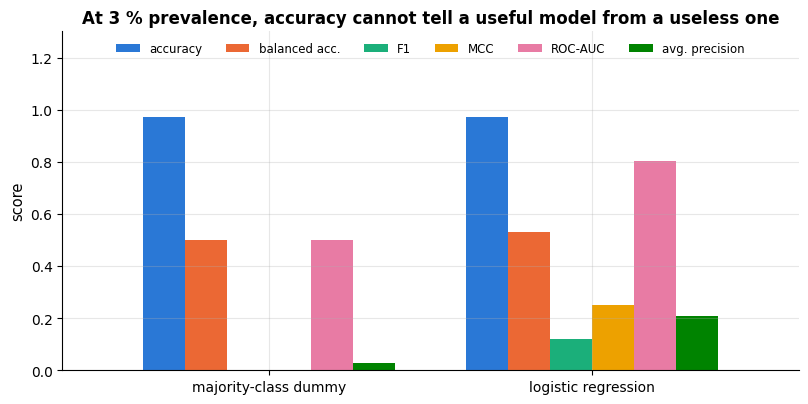

,accuracy,balanced acc.,F1,MCC,ROC-AUC,avg. precision
majority-class dummy,0.970,0.500,0.000,0.00,0.500,0.030
logistic regression,0.972,0.532,0.121,0.25,0.801,0.209


In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             matthews_corrcoef, roc_auc_score, average_precision_score)

# build a rare-event version of the churn data: keep all non-churners, 3 % churners
idx_neg = np.flatnonzero(y_ch == 0)
idx_pos = rng.choice(np.flatnonzero(y_ch == 1), size=int(0.03 / 0.97 * (y_ch == 0).sum()), replace=False)
idx_rare = np.concatenate([idx_neg, idx_pos])
X_rare, y_rare = X_ch.iloc[idx_rare], y_ch[idx_rare]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_rare, y_rare, test_size=0.3, stratify=y_rare,
                                              random_state=RANDOM_STATE)
print(f"rare-event data: {len(y_rare)} rows, prevalence {y_rare.mean():.1%}")

models = {"majority-class dummy": DummyClassifier(strategy="most_frequent"),
          "logistic regression": Pipeline([("prep", preprocess),
                                           ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])}
rows = {}
for name, m in models.items():
    m.fit(Xr_tr, yr_tr)
    pred = m.predict(Xr_te)
    score = m.predict_proba(Xr_te)[:, 1]
    rows[name] = {"accuracy": accuracy_score(yr_te, pred), "balanced acc.": balanced_accuracy_score(yr_te, pred),
                  "F1": f1_score(yr_te, pred, zero_division=0), "MCC": matthews_corrcoef(yr_te, pred),
                  "ROC-AUC": roc_auc_score(yr_te, score), "avg. precision": average_precision_score(yr_te, score)}
metric_table = pd.DataFrame(rows).T

fig, ax = plt.subplots(figsize=(9.5, 4.4))
metric_table.plot.bar(ax=ax, rot=0, color=PALETTE[:6], width=0.78)
ax.set_ylabel("score")
ax.set_ylim(0, 1.3)
ax.set_title("At 3 % prevalence, accuracy cannot tell a useful model from a useless one")
ax.legend(ncol=6, fontsize=8.5, loc="upper center")
plt.show()
metric_table.round(3)

Read that figure carefully, because it contains two lessons rather than one. The dummy
reaches 97 % accuracy while scoring chance level on every prevalence-aware metric
(balanced accuracy 0.50, ROC-AUC 0.50, average precision = the prevalence, $F_1$ = MCC = 0).
And the *logistic regression* scores essentially the same accuracy — yet it is a genuinely
useful model, with an ROC-AUC around 0.80 and an average precision several times the
prevalence. Accuracy cannot separate the two; the ranking metrics can. Its default
threshold is the problem, not its scores — section 6 fixes that. **Never report accuracy
alone on imbalanced data.**

### 5.4 Precision, recall, $F_1$ and $F_\beta$

Two conditional probabilities carry most of the information:

$$
\text{precision} = \frac{TP}{TP + FP} = P(y = 1 \mid \hat{y} = 1),
\qquad
\text{recall} = \frac{TP}{TP + FN} = P(\hat{y} = 1 \mid y = 1).
$$

Precision answers *"when the model raises the alarm, how often is it right?"*; recall (also
**sensitivity** or the **true positive rate**) answers *"of all the real positives, how many
did we catch?"*. They trade off: lowering the threshold raises recall and lowers precision.
Their harmonic mean is the $F_1$ score, and $F_\beta$ tilts the balance,

$$
F_\beta = (1+\beta^2)\,\frac{\text{precision}\cdot\text{recall}}{\beta^2\,\text{precision} + \text{recall}},
$$

with $\beta > 1$ weighting recall more ($\beta = 2$ is common in medical screening) and
$\beta < 1$ weighting precision more. The harmonic mean is used because it is dominated by
the *smaller* of the two: a model with precision 1.0 and recall 0.01 has $F_1 \approx 0.02$,
not 0.5. Two more rates complete the picture:

$$
\text{specificity} = \frac{TN}{TN+FP} = 1 - \text{FPR}, \qquad
\text{NPV} = \frac{TN}{TN+FN}.
$$

Let us compute them all by hand from the four counts and check against scikit-learn.

In [17]:
from sklearn.metrics import precision_score, recall_score, fbeta_score

precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
specificity_manual = tn / (tn + fp)
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)
f2_manual = 5 * precision_manual * recall_manual / (4 * precision_manual + recall_manual)

print(f"{'metric':14s} {'by hand':>9s} {'sklearn':>9s}")
for name, mine, theirs in [
        ("precision", precision_manual, precision_score(y_ch_te, y_pred_ch)),
        ("recall", recall_manual, recall_score(y_ch_te, y_pred_ch)),
        ("specificity", specificity_manual, recall_score(y_ch_te, y_pred_ch, pos_label=0)),
        ("F1", f1_manual, f1_score(y_ch_te, y_pred_ch)),
        ("F2", f2_manual, fbeta_score(y_ch_te, y_pred_ch, beta=2))]:
    print(f"{name:14s} {mine:9.4f} {theirs:9.4f}")

metric           by hand   sklearn
precision         0.6982    0.6982
recall            0.5784    0.5784
specificity       0.8789    0.8789
F1                0.6327    0.6327
F2                0.5990    0.5990


> **Warning.** Precision and recall are defined *with respect to a chosen positive class*.
> `pos_label` decides which one; swapping it turns recall into specificity. In an imbalanced
> problem the interesting class is usually the rare one, and it is usually *not* the one
> scikit-learn picks by default — relabel your target so that $1$ means "the event", as we
> do in section 11.

### 5.5 Balanced accuracy, MCC, Cohen's $\kappa$ and the likelihood ratios

Four more numbers worth knowing, each fixing a specific weakness of the ones above:

| Metric | Definition | What it adds |
|---|---|---|
| **Balanced accuracy** | $\tfrac12(\text{recall} + \text{specificity})$ | accuracy that ignores prevalence; chance level is always 0.5 |
| **MCC** (Matthews) | $\dfrac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP{+}FP)(TP{+}FN)(TN{+}FP)(TN{+}FN)}}$ | the correlation between truth and prediction; $\in[-1,1]$, and the only common metric that uses all four cells symmetrically |
| **Cohen's $\kappa$** | $\dfrac{p_o - p_e}{1 - p_e}$ | agreement corrected for the agreement expected by chance |
| **Likelihood ratios** | $LR^+ = \dfrac{\text{recall}}{1-\text{specificity}}$, $LR^- = \dfrac{1-\text{recall}}{\text{specificity}}$ | prevalence-free; multiply the *pre-test odds* to get the post-test odds — the standard currency in diagnostics |

MCC is the metric to reach for when you want a *single* honest number on an imbalanced
binary problem (Chicco & Jurman, 2020): unlike $F_1$ it cannot be inflated by ignoring the
negative class.

In [18]:
from sklearn.metrics import cohen_kappa_score, class_likelihood_ratios

mcc_manual = (tp * tn - fp * fn) / np.sqrt(float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))
p_o = (tp + tn) / cm.sum()
p_e = ((tp + fp) * (tp + fn) + (tn + fn) * (tn + fp)) / cm.sum() ** 2
kappa_manual = (p_o - p_e) / (1 - p_e)
lr_pos, lr_neg = class_likelihood_ratios(y_ch_te, y_pred_ch)
print(f"balanced accuracy {balanced_accuracy_score(y_ch_te, y_pred_ch):.4f}"
      f"   (by hand {0.5 * (recall_manual + specificity_manual):.4f})")
print(f"MCC               {matthews_corrcoef(y_ch_te, y_pred_ch):.4f}   (by hand {mcc_manual:.4f})")
print(f"Cohen's kappa     {cohen_kappa_score(y_ch_te, y_pred_ch):.4f}   (by hand {kappa_manual:.4f})")
print(f"likelihood ratios LR+ = {lr_pos:.2f}, LR- = {lr_neg:.2f}")

balanced accuracy 0.7286   (by hand 0.7286)
MCC               0.4828   (by hand 0.4828)
Cohen's kappa     0.4784   (by hand 0.4784)
likelihood ratios LR+ = 4.77, LR- = 0.48


### 5.6 Multi-class: micro, macro and weighted averaging

With $K$ classes every metric is computed per class (one-vs-rest) and then averaged. The
averaging scheme is a *choice about what you care about*:

- **micro** — pool all $TP$, $FP$, $FN$ across classes, then compute the metric. Every
  *sample* counts equally, so micro-$F_1$ equals accuracy for single-label problems.
- **macro** — compute the metric per class and take the unweighted mean. Every *class*
  counts equally, so rare classes matter as much as frequent ones.
- **weighted** — like macro but weighting each class by its support. A compromise that is
  easy to misread.

In [19]:
from sklearn.metrics import f1_score as f1

yd_pred = digit_clf.predict(Xd_te)
print(f"digits: micro-F1 {f1(yd_te, yd_pred, average='micro'):.4f}  "
      f"macro-F1 {f1(yd_te, yd_pred, average='macro'):.4f}  "
      f"weighted-F1 {f1(yd_te, yd_pred, average='weighted'):.4f}  "
      f"accuracy {accuracy_score(yd_te, yd_pred):.4f}")
print(classification_report(yd_te, yd_pred, digits=3))

digits: micro-F1 0.9704  macro-F1 0.9704  weighted-F1 0.9705  accuracy 0.9704
              precision    recall  f1-score   support

           0      1.000     0.981     0.991        54
           1      0.897     0.945     0.920        55
           2      1.000     1.000     1.000        53
           3      1.000     1.000     1.000        55
           4      0.963     0.963     0.963        54
           5      1.000     0.964     0.981        55
           6      1.000     0.963     0.981        54
           7      0.982     1.000     0.991        54
           8      0.904     0.904     0.904        52
           9      0.964     0.981     0.972        54

    accuracy                          0.970       540
   macro avg      0.971     0.970     0.970       540
weighted avg      0.971     0.970     0.971       540



`classification_report` prints per-class precision/recall/$F_1$ with support and all three
averages: it should be the first thing you look at after fitting any classifier.

> **Key idea.** Choose the metric *before* you look at the results, from the decision the
> model will support. "Which errors cost more, and to whom?" is a question about the world,
> not about the data — and section 6.5 turns the answer into a threshold.

## 6. Thresholds, ROC curves and precision–recall curves

### 6.1 The threshold is a business decision

`predict()` applies $\hat{y} = \mathbb{1}[\hat{p} \ge 0.5]$. That default is only optimal
when false positives and false negatives cost the same *and* the probabilities are
calibrated. Change either assumption and the optimal threshold moves. Because the threshold
is applied *after* the model is fitted, it can be chosen (and re-chosen) without retraining
— it is a property of the *decision rule*, not of the model.

Sweeping the threshold from 1 to 0 traces out every achievable (FPR, TPR) pair — the ROC
curve — and every achievable (recall, precision) pair — the PR curve.

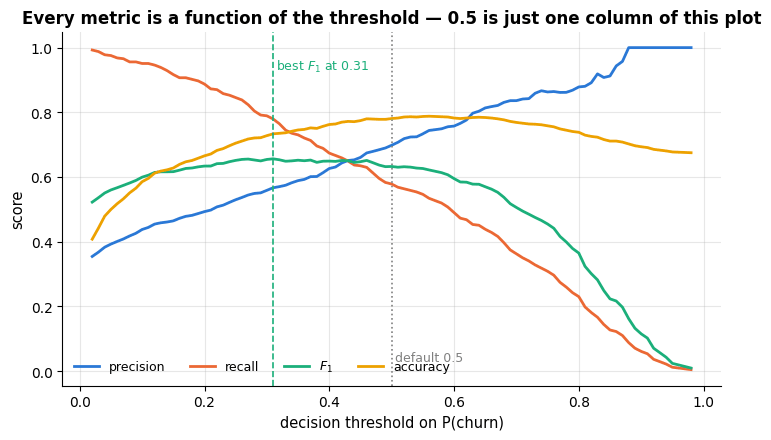

In [20]:
from sklearn.metrics import precision_recall_curve, roc_curve

thresholds = np.linspace(0.02, 0.98, 97)
prec_t, rec_t, f1_t, acc_t = [], [], [], []
for t in thresholds:
    pred_t = (proba_ch >= t).astype(int)
    prec_t.append(precision_score(y_ch_te, pred_t, zero_division=0))
    rec_t.append(recall_score(y_ch_te, pred_t))
    f1_t.append(f1_score(y_ch_te, pred_t, zero_division=0))
    acc_t.append(accuracy_score(y_ch_te, pred_t))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for values, name in [(prec_t, "precision"), (rec_t, "recall"), (f1_t, "$F_1$"), (acc_t, "accuracy")]:
    ax.plot(thresholds, values, lw=2, label=name)
best_f1_t = thresholds[int(np.argmax(f1_t))]
ax.axvline(0.5, color="gray", ls=":", lw=1.2)
ax.text(0.505, 0.03, "default 0.5", color="gray", fontsize=9)
ax.axvline(best_f1_t, color=PALETTE[2], ls="--", lw=1.2)
ax.text(best_f1_t + 0.005, 0.93, f"best $F_1$ at {best_f1_t:.2f}", color=PALETTE[2], fontsize=9)
ax.set_xlabel("decision threshold on P(churn)")
ax.set_ylabel("score")
ax.set_title("Every metric is a function of the threshold — 0.5 is just one column of this plot")
ax.legend(ncol=4, fontsize=9)
plt.show()

### 6.2 ROC and precision–recall curves side by side

The **ROC curve** plots the true positive rate (recall) against the false positive rate
$FPR = FP/(FP+TN) = 1 - \text{specificity}$ as the threshold varies. The diagonal is random
guessing; the top-left corner is perfection. Its summary, **ROC-AUC**, is the area
underneath (Fawcett, 2006).

The **precision–recall curve** plots precision against recall. Its baseline is *not* a
diagonal but the horizontal line at the prevalence $\pi = P(y=1)$, and its summary is
**average precision** $AP = \sum_k (R_k - R_{k-1})P_k$ — a threshold-free average of the
precision achieved at each recall level.

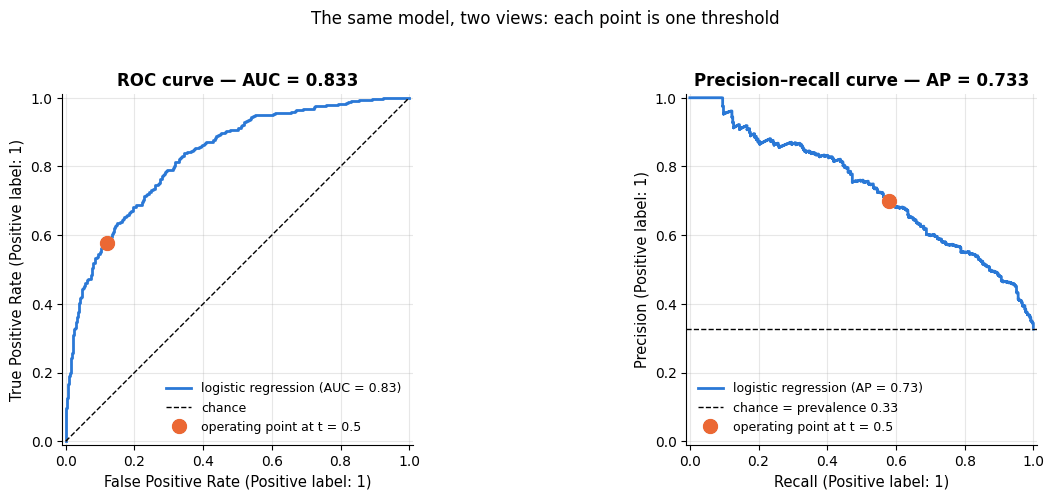

In [21]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
RocCurveDisplay.from_predictions(y_ch_te, proba_ch, ax=axes[0], name="logistic regression",
                                 curve_kwargs={"color": PALETTE[0]})
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
fpr, tpr, thr = roc_curve(y_ch_te, proba_ch)
i50 = int(np.argmin(np.abs(thr - 0.5)))
axes[0].plot(fpr[i50], tpr[i50], "o", ms=10, color=PALETTE[1], label="operating point at t = 0.5")
axes[0].set_title(f"ROC curve — AUC = {roc_auc_score(y_ch_te, proba_ch):.3f}")
axes[0].legend(loc="lower right", fontsize=9)

PrecisionRecallDisplay.from_predictions(y_ch_te, proba_ch, ax=axes[1], color=PALETTE[0], name="logistic regression")
axes[1].axhline(y_ch_te.mean(), color="black", ls="--", lw=1, label=f"chance = prevalence {y_ch_te.mean():.2f}")
p_c, r_c, thr_pr = precision_recall_curve(y_ch_te, proba_ch)
j50 = int(np.argmin(np.abs(thr_pr - 0.5)))
axes[1].plot(r_c[j50], p_c[j50], "o", ms=10, color=PALETTE[1], label="operating point at t = 0.5")
axes[1].set_title(f"Precision–recall curve — AP = {average_precision_score(y_ch_te, proba_ch):.3f}")
axes[1].legend(loc="lower left", fontsize=9)
fig.suptitle("The same model, two views: each point is one threshold", y=1.03)
plt.tight_layout()
plt.show()

### 6.3 What AUC actually measures

ROC-AUC has an interpretation that makes it easy to reason about and impossible to
misunderstand:

$$
\text{AUC} \;=\; P\big(\hat{s}(\mathbf{x}^+) > \hat{s}(\mathbf{x}^-)\big) + \tfrac12 P\big(\hat{s}(\mathbf{x}^+) = \hat{s}(\mathbf{x}^-)\big),
$$

for a randomly drawn positive $\mathbf{x}^+$ and negative $\mathbf{x}^-$. It is a measure of
**ranking quality** and nothing else: AUC is invariant to any monotone transformation of the
scores, so it says nothing about whether the probabilities are calibrated. It equals the
normalised Mann–Whitney $U$ statistic — which we can verify by brute force over all
positive–negative pairs.

In [22]:
pos_scores = proba_ch[y_ch_te == 1]
neg_scores = proba_ch[y_ch_te == 0]
comparisons = pos_scores[:, None] - neg_scores[None, :]
auc_by_hand = (comparisons > 0).mean() + 0.5 * (comparisons == 0).mean()
print(f"pairs compared: {comparisons.size:,}")
print(f"AUC by counting pairs : {auc_by_hand:.10f}")
print(f"roc_auc_score         : {roc_auc_score(y_ch_te, proba_ch):.10f}")

pairs compared: 343,536
AUC by counting pairs : 0.8329723814
roc_auc_score         : 0.8329723814


> **Warning.** A high AUC does **not** mean the model is usable. AUC averages over *all*
> thresholds, including ones no-one would ever deploy, and it is insensitive to prevalence.
> Always report AUC together with the metric at the operating point you will actually use.

### 6.4 Why precision–recall is the better view under imbalance

Because FPR has $TN$ in its denominator, and $TN$ is huge when negatives dominate, the ROC
curve is almost unchanged when the positive class becomes rare. Precision, whose
denominator $TP + FP$ has no $TN$ in it, collapses. Davis & Goadrich (2006) and Saito &
Rehmsmeier (2015) make the argument formally; let us make it visually by subsampling the
positives of our test set to three different prevalences.

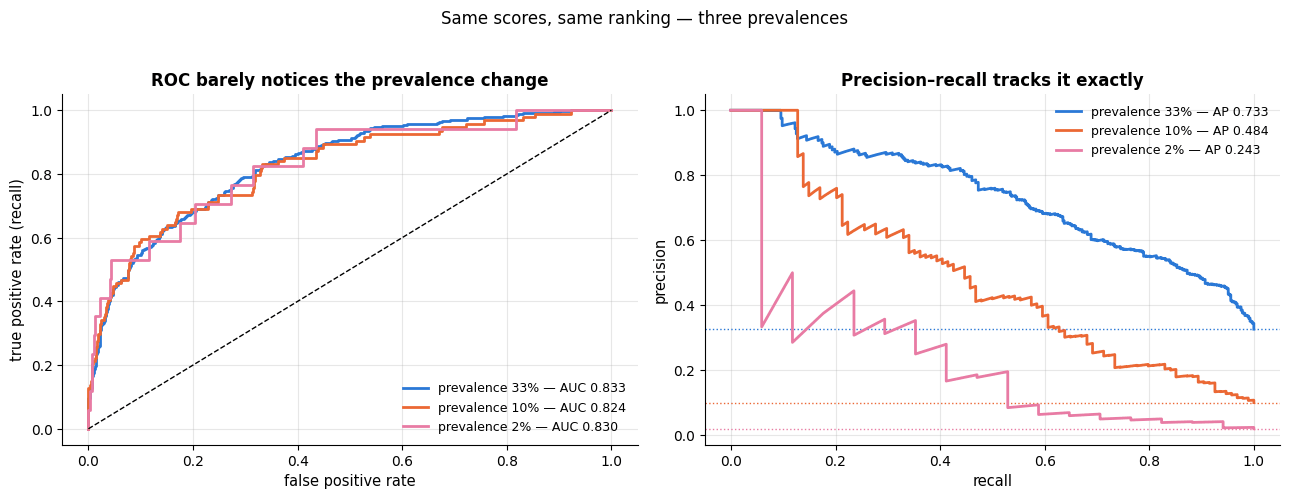

In [23]:
def subsample_to_prevalence(scores, labels, prevalence, rng=rng):
    """Keep all negatives and as many random positives as the target prevalence allows."""
    neg = np.flatnonzero(labels == 0)
    n_pos = int(round(prevalence / (1 - prevalence) * len(neg)))
    pos = rng.choice(np.flatnonzero(labels == 1), size=min(n_pos, int((labels == 1).sum())), replace=False)
    keep = np.concatenate([neg, pos])
    return scores[keep], labels[keep]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for prevalence, colour in zip([0.33, 0.10, 0.02], [PALETTE[0], PALETTE[1], PALETTE[4]]):
    s_sub, y_sub = subsample_to_prevalence(proba_ch, y_ch_te, prevalence)
    fpr_s, tpr_s, _ = roc_curve(y_sub, s_sub)
    prec_s, rec_s, _ = precision_recall_curve(y_sub, s_sub)
    axes[0].plot(fpr_s, tpr_s, lw=2, color=colour,
                 label=f"prevalence {y_sub.mean():.0%} — AUC {roc_auc_score(y_sub, s_sub):.3f}")
    axes[1].plot(rec_s, prec_s, lw=2, color=colour,
                 label=f"prevalence {y_sub.mean():.0%} — AP {average_precision_score(y_sub, s_sub):.3f}")
    axes[1].axhline(y_sub.mean(), color=colour, ls=":", lw=1)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate (recall)")
axes[0].set_title("ROC barely notices the prevalence change")
axes[0].legend(loc="lower right", fontsize=9)
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision–recall tracks it exactly")
axes[1].legend(loc="upper right", fontsize=9)
fig.suptitle("Same scores, same ranking — three prevalences", y=1.03)
plt.tight_layout()
plt.show()

The three ROC curves lie almost on top of each other while the PR curves fall apart. If your
positives are rare and you care about the workload created by false alarms, report AP.

### 6.5 Choosing the threshold from a cost matrix

Suppose keeping a churning customer earns $c_{FN} = 300$ (the margin lost if we miss them)
and a retention offer to someone who would have stayed costs $c_{FP} = 40$. The expected
cost per customer at threshold $t$ is

$$
\text{cost}(t) \;=\; \frac{c_{FN}\,FN(t) + c_{FP}\,FP(t)}{n},
$$

and the optimum for a *calibrated* model is at $t^\star = c_{FP}/(c_{FP} + c_{FN})$ — here
$40/340 \approx 0.12$, far from 0.5. (Derivation: act positively when the expected cost of
not acting, $c_{FN}\,p$, exceeds that of acting, $c_{FP}(1-p)$.) Rather than trusting the
formula, tune the threshold on **cross-validated** predictions with
`TunedThresholdClassifierCV`, which is the scikit-learn ≥ 1.5 tool for exactly this job and
avoids the optimism of tuning on the test set.

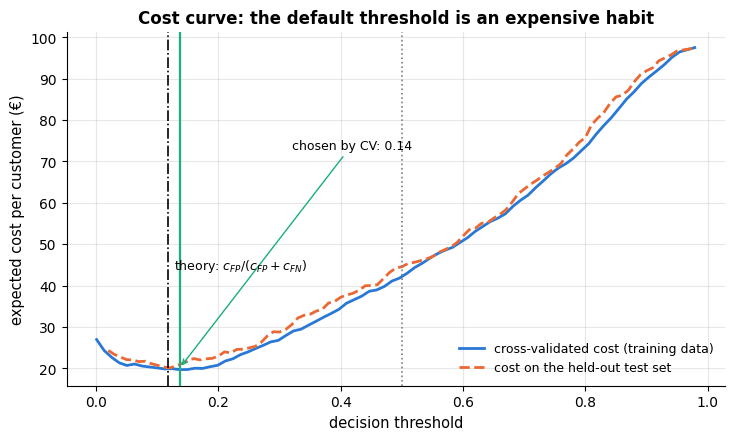

cost at t = 0.50 : €36.96 per customer
cost at t = 0.14 : €20.75 per customer


In [24]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import TunedThresholdClassifierCV

COST_FN, COST_FP = 300.0, 40.0

def expected_cost(y_true, y_pred):
    """Average cost per customer (lower is better)."""
    tn_, fp_, fn_, tp_ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return (COST_FN * fn_ + COST_FP * fp_) / len(y_true)

cost_scorer = make_scorer(expected_cost, greater_is_better=False, response_method="predict")
tuned = TunedThresholdClassifierCV(churn_clf, scoring=cost_scorer, cv=5, thresholds=80,
                                   store_cv_results=True, random_state=RANDOM_STATE).fit(X_ch_tr, y_ch_tr)

cost_te = [expected_cost(y_ch_te, (proba_ch >= t).astype(int)) for t in thresholds]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(tuned.cv_results_["thresholds"], -tuned.cv_results_["scores"], lw=2, color=PALETTE[0],
        label="cross-validated cost (training data)")
ax.plot(thresholds, cost_te, lw=2, ls="--", color=PALETTE[1], label="cost on the held-out test set")
ax.axvline(0.5, color="gray", ls=":", lw=1.2)
ax.axvline(tuned.best_threshold_, color=PALETTE[2], lw=1.6)
ax.axvline(COST_FP / (COST_FP + COST_FN), color="black", ls="-.", lw=1.2)
ax.annotate(f"chosen by CV: {tuned.best_threshold_:.2f}", xy=(tuned.best_threshold_, np.min(cost_te)),
            xytext=(0.32, np.max(cost_te) * 0.75), fontsize=9,
            arrowprops=dict(arrowstyle="->", color=PALETTE[2]))
ax.text(COST_FP / (COST_FP + COST_FN) + 0.01, np.max(cost_te) * 0.45,
        "theory: $c_{FP}/(c_{FP}+c_{FN})$", fontsize=9)
ax.set_xlabel("decision threshold")
ax.set_ylabel("expected cost per customer (€)")
ax.set_title("Cost curve: the default threshold is an expensive habit")
ax.legend(fontsize=9)
plt.show()
print(f"cost at t = 0.50 : €{expected_cost(y_ch_te, churn_clf.predict(X_ch_te)):.2f} per customer")
print(f"cost at t = {tuned.best_threshold_:.2f} : €{expected_cost(y_ch_te, tuned.predict(X_ch_te)):.2f} per customer")

Tuning the threshold — a single number, chosen after fitting, at zero modelling cost —
roughly halves the expected cost. In most applied projects this is a far larger win than
switching model families.

> **Note.** `FixedThresholdClassifier(model, threshold=t)` wraps a fitted model so that
> `predict` uses your threshold, which keeps the rest of the pipeline (and every
> scikit-learn scorer) unaware that anything changed.

## 7. Probability calibration

### 7.1 Reliability diagrams, log loss and the Brier score

A model is **calibrated** if among the cases it gives probability $0.7$, about 70 % really
are positive. Calibration is what makes a probability usable in the expected-cost
calculation above; ranking metrics such as AUC are blind to it. The diagnostic is the
**reliability diagram**: bin the predictions by predicted probability and plot the observed
frequency against the mean prediction in each bin. Perfect calibration is the diagonal.

Two proper scoring rules summarise it in a number:

$$
\text{log loss} = -\frac{1}{n}\sum_i \big[y_i\log p_i + (1-y_i)\log(1-p_i)\big],
\qquad
\text{Brier} = \frac{1}{n}\sum_i (p_i - y_i)^2 .
$$

Both are minimised only by the true probabilities ("proper"), and both mix *discrimination*
(is the ranking good?) with *calibration* (are the levels right?). The Brier score is bounded
in $[0,1]$ and forgiving of confident mistakes; log loss is unbounded and punishes them
brutally. Murphy's decomposition splits the Brier score into
$\text{reliability} - \text{resolution} + \text{uncertainty}$, where the first term is
exactly what the reliability diagram draws.

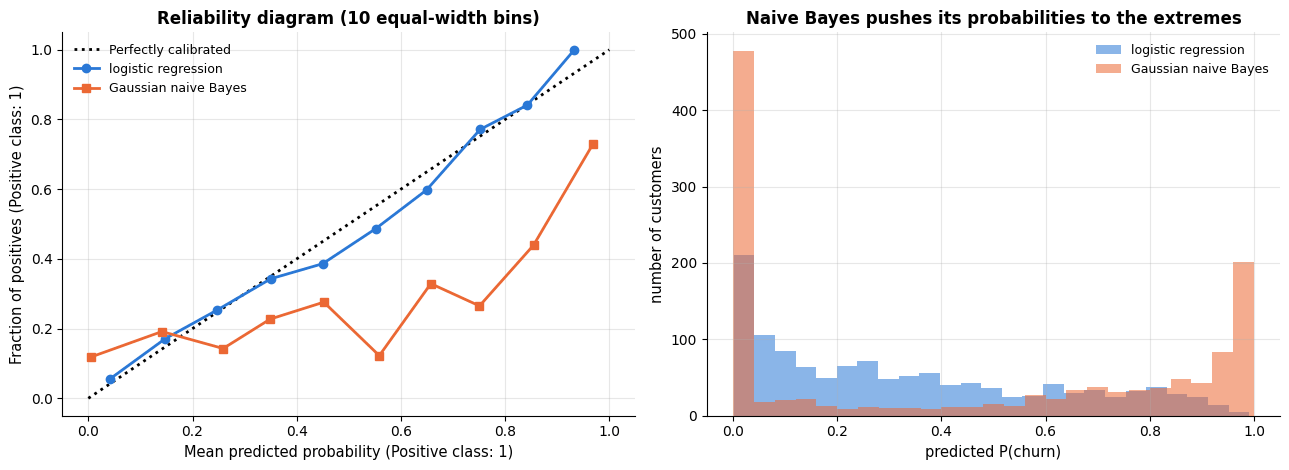

logistic regression    log loss 0.4606   Brier 0.1500   ROC-AUC 0.8330
Gaussian naive Bayes   log loss 0.9303   Brier 0.2217   ROC-AUC 0.8139


In [25]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.naive_bayes import GaussianNB

nb_pipe = Pipeline([("prep", preprocess), ("nb", GaussianNB())]).fit(X_ch_tr, y_ch_tr)
proba_nb = nb_pipe.predict_proba(X_ch_te)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"height_ratios": [1]})
for name, p_hat, colour, marker in [("logistic regression", proba_ch, PALETTE[0], "o"),
                                    ("Gaussian naive Bayes", proba_nb, PALETTE[1], "s")]:
    CalibrationDisplay.from_predictions(y_ch_te, p_hat, n_bins=10, ax=axes[0], name=name,
                                        color=colour, marker=marker)
    axes[1].hist(p_hat, bins=25, alpha=0.55, color=colour, label=name)
axes[0].set_title("Reliability diagram (10 equal-width bins)")
axes[0].legend(loc="upper left", fontsize=9)
axes[1].set_xlabel("predicted P(churn)")
axes[1].set_ylabel("number of customers")
axes[1].set_title("Naive Bayes pushes its probabilities to the extremes")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

for name, p_hat in [("logistic regression", proba_ch), ("Gaussian naive Bayes", proba_nb)]:
    print(f"{name:22s} log loss {log_loss(y_ch_te, p_hat):.4f}   Brier {brier_score_loss(y_ch_te, p_hat):.4f}   "
          f"ROC-AUC {roc_auc_score(y_ch_te, p_hat):.4f}")

Note the pattern: naive Bayes can have a respectable AUC (its *ranking* is fine) and a
terrible Brier score (its *levels* are not). That is the separation of discrimination from
calibration in one table. Notebook 8, §4.5 explains why the independence assumption causes
it.

> **Key idea.** Logistic regression fitted by maximum likelihood is calibrated *by
> construction* on the training distribution: the gradient condition
> $\mathbf{X}^\top(\mathbf{p}-\mathbf{y}) = \mathbf{0}$ says the predicted and observed
> counts match in every feature direction (with an intercept, the totals match exactly).
> This is a real and often overlooked advantage over margin-based and generative
> classifiers.

### 7.2 Repairing calibration: Platt scaling and isotonic regression

`CalibratedClassifierCV` fits a one-dimensional map from raw scores to calibrated
probabilities on held-out folds:

- **`method="sigmoid"`** — Platt scaling (Platt, 1999): fit $\sigma(as + b)$ by maximum
  likelihood. Two parameters, so it works with a few hundred samples, but it can only
  correct sigmoid-shaped distortion.
- **`method="isotonic"`** — fit a non-decreasing step function (pool-adjacent-violators).
  Non-parametric and far more flexible, but it needs roughly $\ge 1000$ calibration samples
  and can overfit below that.

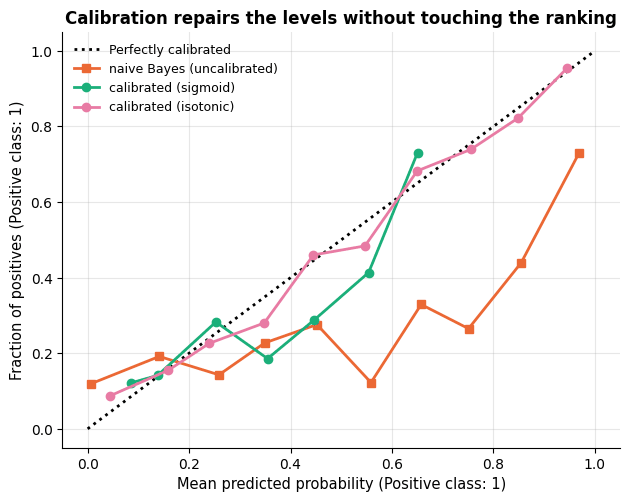

,log loss,Brier,ROC-AUC
model,,,
naive Bayes (uncalibrated),0.9303,0.2217,0.8139
naive Bayes + sigmoid,0.5094,0.1660,0.8143
naive Bayes + isotonic,0.4747,0.1538,0.8139


In [26]:
from sklearn.calibration import CalibratedClassifierCV

fig, ax = plt.subplots(figsize=(7.2, 5.4))
CalibrationDisplay.from_predictions(y_ch_te, proba_nb, n_bins=10, ax=ax,
                                    name="naive Bayes (uncalibrated)", color=PALETTE[1], marker="s")
calibration_rows = [{"model": "naive Bayes (uncalibrated)", "log loss": log_loss(y_ch_te, proba_nb),
                     "Brier": brier_score_loss(y_ch_te, proba_nb), "ROC-AUC": roc_auc_score(y_ch_te, proba_nb)}]
for method, colour in [("sigmoid", PALETTE[2]), ("isotonic", PALETTE[4])]:
    cal = CalibratedClassifierCV(Pipeline([("prep", preprocess), ("nb", GaussianNB())]),
                                 method=method, cv=5).fit(X_ch_tr, y_ch_tr)
    p_cal = cal.predict_proba(X_ch_te)[:, 1]
    CalibrationDisplay.from_predictions(y_ch_te, p_cal, n_bins=10, ax=ax, name=f"calibrated ({method})",
                                        color=colour, marker="o")
    calibration_rows.append({"model": f"naive Bayes + {method}", "log loss": log_loss(y_ch_te, p_cal),
                             "Brier": brier_score_loss(y_ch_te, p_cal), "ROC-AUC": roc_auc_score(y_ch_te, p_cal)})
ax.set_title("Calibration repairs the levels without touching the ranking")
ax.legend(loc="upper left", fontsize=9)
plt.show()
pd.DataFrame(calibration_rows).set_index("model").round(4)

The AUC barely moves (both maps are monotone, so the ranking is preserved) while log loss
and the Brier score improve substantially. Calibrate whenever a downstream decision uses the
probability as a number rather than as a rank.

## 8. Class imbalance

Three tools, in increasing order of how much they disturb the model:

1. **Move the threshold** (section 6.5). Cheapest, most transparent, and usually enough.
   Nothing about the fitted model changes.
2. **Re-weight the classes**: `class_weight="balanced"` multiplies each class's loss
   contribution by $n/(K\,n_k)$, which is equivalent to duplicating minority samples. It
   changes the fitted coefficients (and therefore also decalibrates the probabilities
   towards the minority class).
3. **Resample the data**: random over/under-sampling or SMOTE (Chawla et al., 2002).
   Resampling must happen *inside* the cross-validation folds, never before splitting —
   otherwise synthetic copies of validation points end up in training. `imbalanced-learn`
   provides pipeline-aware versions; plain scikit-learn does not.

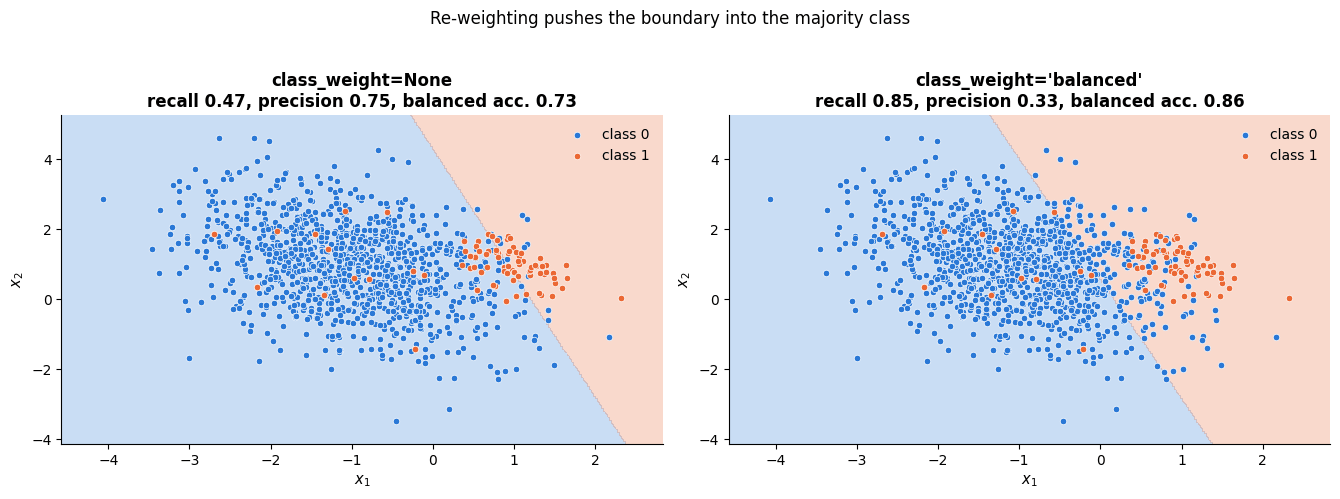

,accuracy,recall,precision,balanced acc.,Brier
class_weight,,,,,
None,0.951,0.465,0.755,0.727,0.036
balanced,0.868,0.849,0.335,0.859,0.104


In [27]:
X_imb, y_imb = make_classification(n_samples=1200, n_features=2, n_redundant=0, n_informative=2,
                                   n_clusters_per_class=1, weights=[0.94, 0.06], class_sep=1.0,
                                   flip_y=0.02, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
imb_rows = []
for ax, weight in zip(axes, [None, "balanced"]):
    m = LogisticRegression(class_weight=weight, max_iter=2000).fit(X_imb, y_imb)
    pred = m.predict(X_imb)
    plot_decision_boundary(m, X_imb, y_imb, ax=ax, feature_names=("$x_1$", "$x_2$"),
                           title=f"class_weight={weight!r}\nrecall {recall_score(y_imb, pred):.2f}, "
                                 f"precision {precision_score(y_imb, pred, zero_division=0):.2f}, "
                                 f"balanced acc. {balanced_accuracy_score(y_imb, pred):.2f}")
    imb_rows.append({"class_weight": str(weight), "accuracy": accuracy_score(y_imb, pred),
                     "recall": recall_score(y_imb, pred), "precision": precision_score(y_imb, pred, zero_division=0),
                     "balanced acc.": balanced_accuracy_score(y_imb, pred),
                     "Brier": brier_score_loss(y_imb, m.predict_proba(X_imb)[:, 1])})
fig.suptitle("Re-weighting pushes the boundary into the majority class", y=1.03)
plt.tight_layout()
plt.show()
pd.DataFrame(imb_rows).set_index("class_weight").round(3)

Balancing buys recall and costs precision and calibration — the same trade the threshold
makes, but baked into the coefficients. Prefer thresholding when you need calibrated
probabilities; prefer `class_weight` when the minority class is so rare that the
unweighted fit barely separates it at all.

## 9. Strengths, weaknesses and when to use logistic regression

| | |
|---|---|
| **Assumptions / inductive bias** | the log-odds are a *linear* function of the features; observations are independent given $\mathbf{x}$; with a penalty, small coefficients are preferred |
| **Strengths** | convex objective → a unique optimum and reproducible fits; well-calibrated probabilities out of the box; coefficients readable as odds ratios; cheap to train and to serve; handles $d > n$ with regularisation; $\ell_1$ gives built-in feature selection; extends cleanly to $K$ classes and to the whole GLM family |
| **Weaknesses / failure modes** | cannot represent a non-linear boundary without explicit feature engineering; sensitive to feature scaling when penalised; the MLE does not exist for perfectly separable data (coefficients diverge); coefficients become unstable and uninterpretable under strong collinearity; assumes additive effects unless you add interaction terms; outliers in *feature* space still have leverage |
| **Data it suits** | any $n$; $d$ from a handful to millions (sparse text); numeric features (standardised) and one-hot categoricals; needs no missing values (impute first); noise-tolerant |
| **Complexity** | training $O(n d)$ per iteration for first-order solvers, $O(nd^2 + d^3)$ per Newton step; prediction $O(d)$; memory $O(d)$ — among the cheapest models to deploy |
| **Interpretability** | high: $e^{w_j}$ is the odds ratio per unit of $x_j$; the sign is the direction; standardised coefficients rank feature importance (with the collinearity caveat of notebook 6, §4.2) |
| **Use it when** | you need probabilities, an auditable model, a strong baseline, or $d \gg n$ with a mostly linear signal |
| **Avoid it when** | the boundary is strongly non-linear and you cannot engineer the features for it — reach for trees/ensembles (notebooks 9–10) or kernel SVMs (notebook 11) |

### 9.1 Demonstrated failure 1: a boundary that is not a line

The inductive bias is the whole story. On concentric classes the best possible *linear*
model is a coin flip; the same model with a degree-2 feature expansion — which makes
$x_1^2 + x_2^2$ available — solves the problem exactly, and so does a decision tree
(notebook 9) with no feature engineering at all.

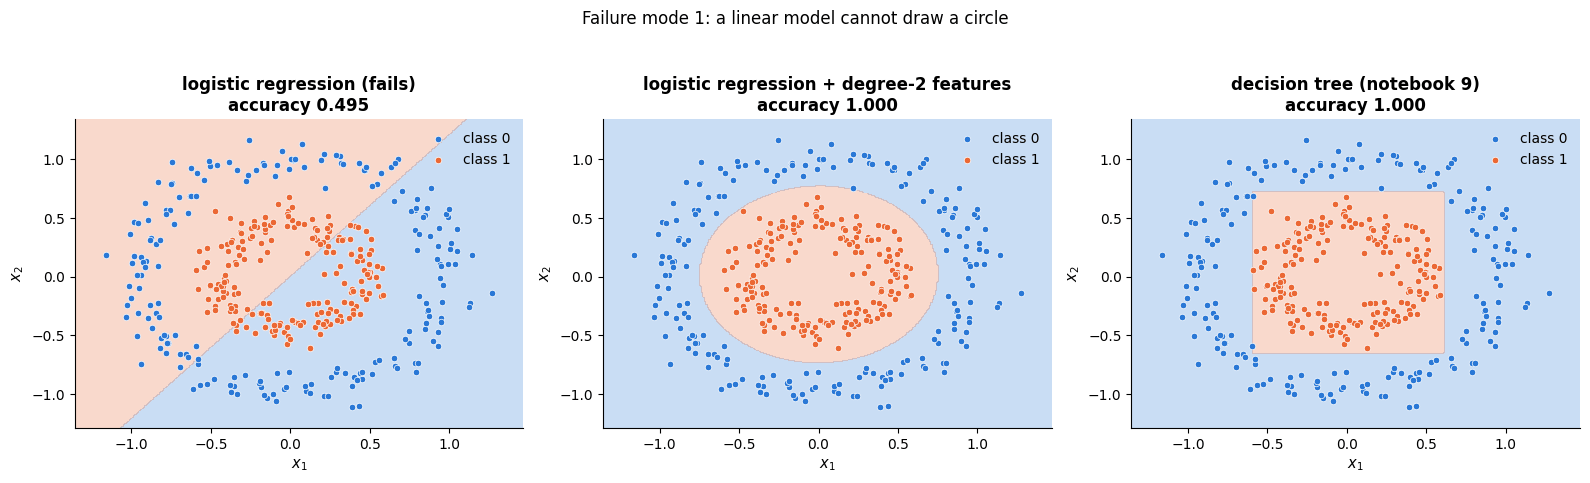

In [28]:
from sklearn.datasets import make_circles
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier

X_circ, y_circ = make_circles(n_samples=400, noise=0.09, factor=0.45, random_state=RANDOM_STATE)
candidates = {
    "logistic regression (fails)": LogisticRegression(),
    "logistic regression + degree-2 features": make_pipeline(PolynomialFeatures(2), LogisticRegression(C=10.0, max_iter=2000)),
    "decision tree (notebook 9)": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (name, model) in zip(axes, candidates.items()):
    model.fit(X_circ, y_circ)
    plot_decision_boundary(model, X_circ, y_circ, ax=ax, feature_names=("$x_1$", "$x_2$"),
                           title=f"{name}\naccuracy {model.score(X_circ, y_circ):.3f}")
fig.suptitle("Failure mode 1: a linear model cannot draw a circle", y=1.04)
plt.tight_layout()
plt.show()

### 9.2 Demonstrated failure 2: perfect separation

If a hyperplane separates the training classes exactly, the likelihood can always be
increased by scaling $\mathbf{w}$ up: the sigmoid becomes a step function, every training
probability tends to 0 or 1, and the loss tends to 0 without ever attaining it. **The
maximum-likelihood estimate does not exist** (Albert & Anderson, 1984). In practice the
optimiser stops at whatever `max_iter` allows, standard errors explode, and the model is
absurdly over-confident. The symptom is easy to spot: coefficients that keep growing as you
weaken the penalty.

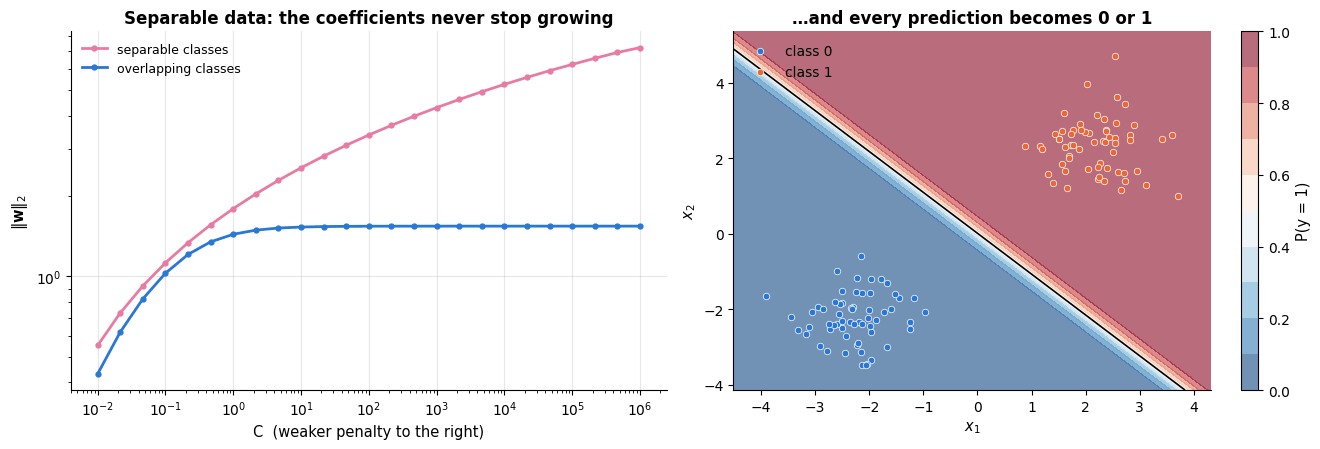

separable data, C = 1e6: ||w|| = 7.2, min P(correct class) = 0.999999


In [29]:
from sklearn.datasets import make_blobs

X_sep, y_sep = make_blobs(n_samples=120, centers=[[-2.2, -2.2], [2.2, 2.2]], cluster_std=0.65,
                          random_state=RANDOM_STATE)
X_ovl, y_ovl = make_blobs(n_samples=120, centers=[[-1.0, -1.0], [1.0, 1.0]], cluster_std=1.5,
                          random_state=RANDOM_STATE)
Cs_sep = np.logspace(-2, 6, 25)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for Xs_, ys_, name, colour in [(X_sep, y_sep, "separable classes", PALETTE[4]),
                               (X_ovl, y_ovl, "overlapping classes", PALETTE[0])]:
    norms = [np.linalg.norm(LogisticRegression(C=C, max_iter=20000, tol=1e-8).fit(Xs_, ys_).coef_)
             for C in Cs_sep]
    axes[0].plot(Cs_sep, norms, "-o", ms=3.5, color=colour, label=name)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("C  (weaker penalty to the right)")
axes[0].set_ylabel(r"$\|\mathbf{w}\|_2$")
axes[0].set_title("Separable data: the coefficients never stop growing")
axes[0].legend(fontsize=9)

sep_model = LogisticRegression(C=1e6, max_iter=20000, tol=1e-8).fit(X_sep, y_sep)
plot_decision_boundary(sep_model, X_sep, y_sep, ax=axes[1], proba=True, feature_names=("$x_1$", "$x_2$"),
                       title="…and every prediction becomes 0 or 1")
plt.tight_layout()
plt.show()
print(f"separable data, C = 1e6: ||w|| = {np.linalg.norm(sep_model.coef_):.1f}, "
      f"min P(correct class) = {sep_model.predict_proba(X_sep).max(axis=1).min():.6f}")

On the overlapping data the coefficient norm plateaus — the optimum is finite. On the
separable data it grows without bound, roughly like $\log C$. **The fix is the penalty**:
keep `C` finite (the default `C=1.0` is already enough), and never fit an unpenalised
logistic regression to wide data. This is also why the perfectly-separating boundary chosen
by a large `C` is arbitrary among many separating lines — the maximum-*margin* choice is what
support vector machines add (notebook 11).

## 10. Tuning guide

| Hyper-parameter | Controls | Range / scale | Bias–variance | Default |
|---|---|---|---|---|
| `C` | inverse regularisation strength | $10^{-4}$ … $10^{4}$, **log** | ↑ `C` → ↓ bias, ↑ variance | `1.0` |
| `l1_ratio` | penalty shape: 0 = $\ell_2$, 1 = $\ell_1$, between = elastic net | 0 … 1, linear (try 0, 0.5, 1 first) | ↑ ratio → sparser, higher bias per feature kept | `0.0` |
| `class_weight` | per-class loss weight | `None` or `"balanced"` | shifts the boundary, not the capacity | `None` |
| `solver` | optimisation algorithm | categorical | none (same optimum) — a speed/penalty choice | `"lbfgs"` |
| `max_iter` | iteration budget | 100 … 5000 | none, if large enough | `100` (often too small) |
| **decision threshold** | the operating point | 0 … 1, linear | trades precision against recall | 0.5 |
| `fit_intercept` | free bias term | `True`/`False` | leave it `True` | `True` |

**Tune in this order.**

1. **`C`** — by far the most important. Search a log grid; look for a plateau rather than a
   spike.
2. **`l1_ratio`** — only if you want sparsity or have many irrelevant features. It
   *interacts strongly with `C`*, because both control how many coefficients survive: an
   $\ell_1$ model needs a larger `C` than an $\ell_2$ model to keep the same effective
   capacity. Search them jointly (section 10.2).
3. **`class_weight`** and the **threshold** — these address imbalance, not capacity. Tune
   them *after* `C`, against the metric you actually care about.
4. **`solver` / `max_iter`** — computational, not statistical. Choose by the penalty you
   need and the size of the problem; raise `max_iter` until the `ConvergenceWarning`
   disappears.

### 10.1 The regularisation strength `C`

We use a synthetic dataset with 5 informative features among 25 — a setting where the
penalty choice genuinely matters — and 5-fold stratified CV throughout.

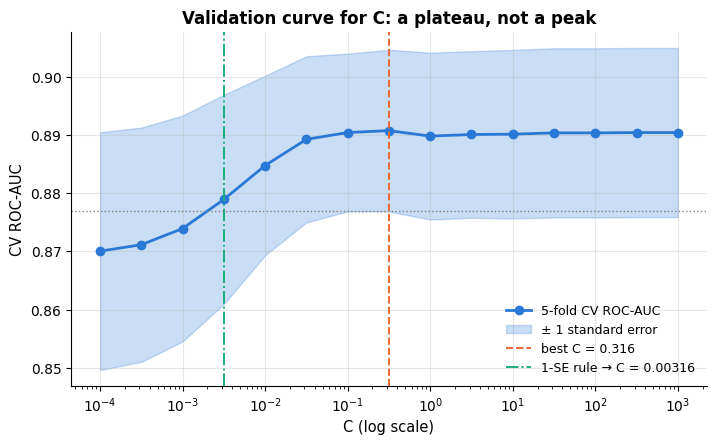

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

X_tune, y_tune = make_classification(n_samples=600, n_features=25, n_informative=5, n_redundant=3,
                                     class_sep=1.0, flip_y=0.05, random_state=RANDOM_STATE)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_mean_se(model, X=X_tune, y=y_tune, scoring="roc_auc"):
    """CV mean and standard error of the mean."""
    s = cross_val_score(model, X, y, cv=cv5, scoring=scoring)
    return s.mean(), s.std(ddof=1) / np.sqrt(len(s))

Cs_tune = np.logspace(-4, 3, 15)
mean_l2 = np.array([cv_mean_se(make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=5000)))
                    for C in Cs_tune])
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.plot(Cs_tune, mean_l2[:, 0], "-o", color=PALETTE[0], label="5-fold CV ROC-AUC")
ax.fill_between(Cs_tune, mean_l2[:, 0] - mean_l2[:, 1], mean_l2[:, 0] + mean_l2[:, 1],
                alpha=0.25, color=PALETTE[0], label="± 1 standard error")
best_i = int(np.argmax(mean_l2[:, 0]))
one_se_floor = mean_l2[best_i, 0] - mean_l2[best_i, 1]
simplest = Cs_tune[np.flatnonzero(mean_l2[:, 0] >= one_se_floor)[0]]     # smallest C within 1 SE = simplest model
ax.axvline(Cs_tune[best_i], color=PALETTE[1], ls="--", lw=1.4, label=f"best C = {Cs_tune[best_i]:.3g}")
ax.axvline(simplest, color=PALETTE[2], ls="-.", lw=1.4, label=f"1-SE rule → C = {simplest:.3g}")
ax.axhline(one_se_floor, color="gray", ls=":", lw=1)
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("CV ROC-AUC")
ax.set_title("Validation curve for C: a plateau, not a peak")
ax.legend(fontsize=9, loc="lower right")
plt.show()

### 10.2 The penalty, and its interaction with `C`

Because `l1_ratio` and `C` both decide how much coefficient mass survives, the two must be
searched together. The same CV grid gives both the per-penalty validation curves and the
2-D heat-map.

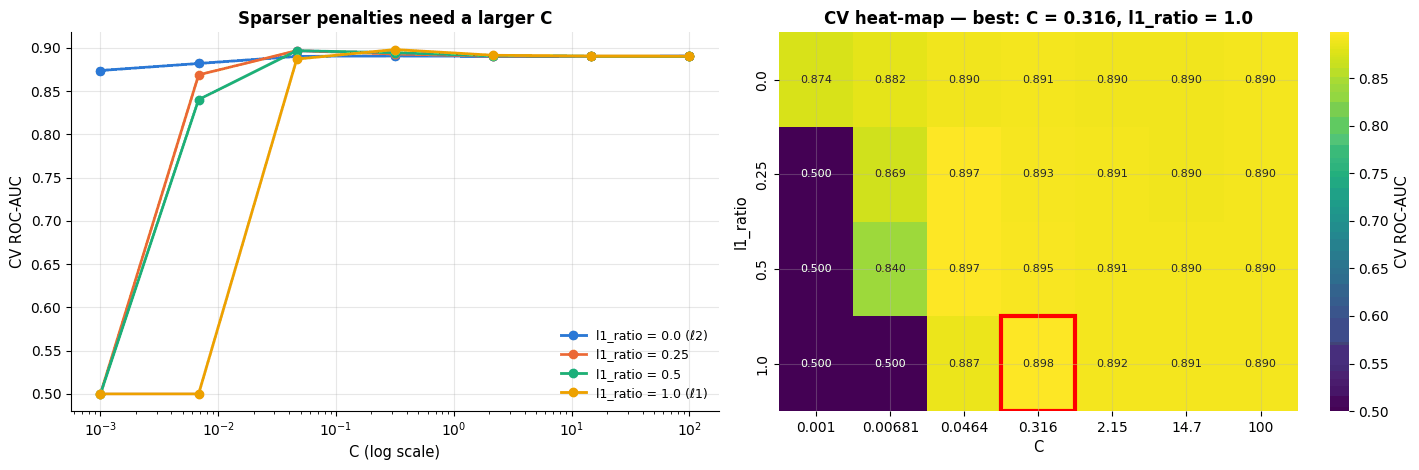

In [31]:
ratios = [0.0, 0.25, 0.5, 1.0]
Cs_grid = np.logspace(-3, 2, 7)
grid_scores = np.zeros((len(ratios), len(Cs_grid)))
for i, ratio in enumerate(ratios):
    for j, C in enumerate(Cs_grid):
        model = make_pipeline(StandardScaler(),
                              LogisticRegression(C=C, l1_ratio=ratio, solver="saga",
                                                 max_iter=8000, random_state=RANDOM_STATE))
        grid_scores[i, j] = cross_val_score(model, X_tune, y_tune, cv=cv5, scoring="roc_auc").mean()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
for i, ratio in enumerate(ratios):
    axes[0].plot(Cs_grid, grid_scores[i], "-o", lw=2, color=PALETTE[i],
                 label=f"l1_ratio = {ratio}" + (" (ℓ2)" if ratio == 0 else " (ℓ1)" if ratio == 1 else ""))
axes[0].set_xscale("log")
axes[0].set_xlabel("C (log scale)")
axes[0].set_ylabel("CV ROC-AUC")
axes[0].set_title("Sparser penalties need a larger C")
axes[0].legend(fontsize=9, loc="lower right")

sns.heatmap(grid_scores, ax=axes[1], cmap="viridis", annot=True, fmt=".3f", annot_kws={"size": 8},
            xticklabels=[f"{c:.3g}" for c in Cs_grid], yticklabels=[str(r) for r in ratios],
            cbar_kws={"label": "CV ROC-AUC"})
i_best, j_best = np.unravel_index(grid_scores.argmax(), grid_scores.shape)
axes[1].add_patch(plt.Rectangle((j_best, i_best), 1, 1, fill=False, edgecolor="red", lw=3))
axes[1].set_xlabel("C")
axes[1].set_ylabel("l1_ratio")
axes[1].set_title(f"CV heat-map — best: C = {Cs_grid[j_best]:.3g}, l1_ratio = {ratios[i_best]}")
plt.tight_layout()
plt.show()

The staircase is the interaction: the good region starts at a small `C` for $\ell_2$ and
only at a larger `C` for $\ell_1$. The cells at exactly 0.500 are models whose coefficients
have all been shrunk to zero — an $\ell_1$ penalty that strong predicts the majority class
and nothing else. A one-dimensional search over `C` at `l1_ratio=1` with the grid tuned for
$\ell_2$ would have concluded that $\ell_1$ is useless, when it simply needed a different
`C`. Note also how flat the plateau is: every configuration to the right of the staircase is
within 0.01 AUC of the best.

### 10.3 What `C` does to the fitted function

With raw features a linear boundary changes only its slope as `C` varies, which is hard to
see. Expand the features to degree 5 on a problem that genuinely needs a curve (the two
moons) and the effect becomes obvious: `C` controls how much the boundary is allowed to
wiggle — exactly the role it plays for an SVM (notebook 11).

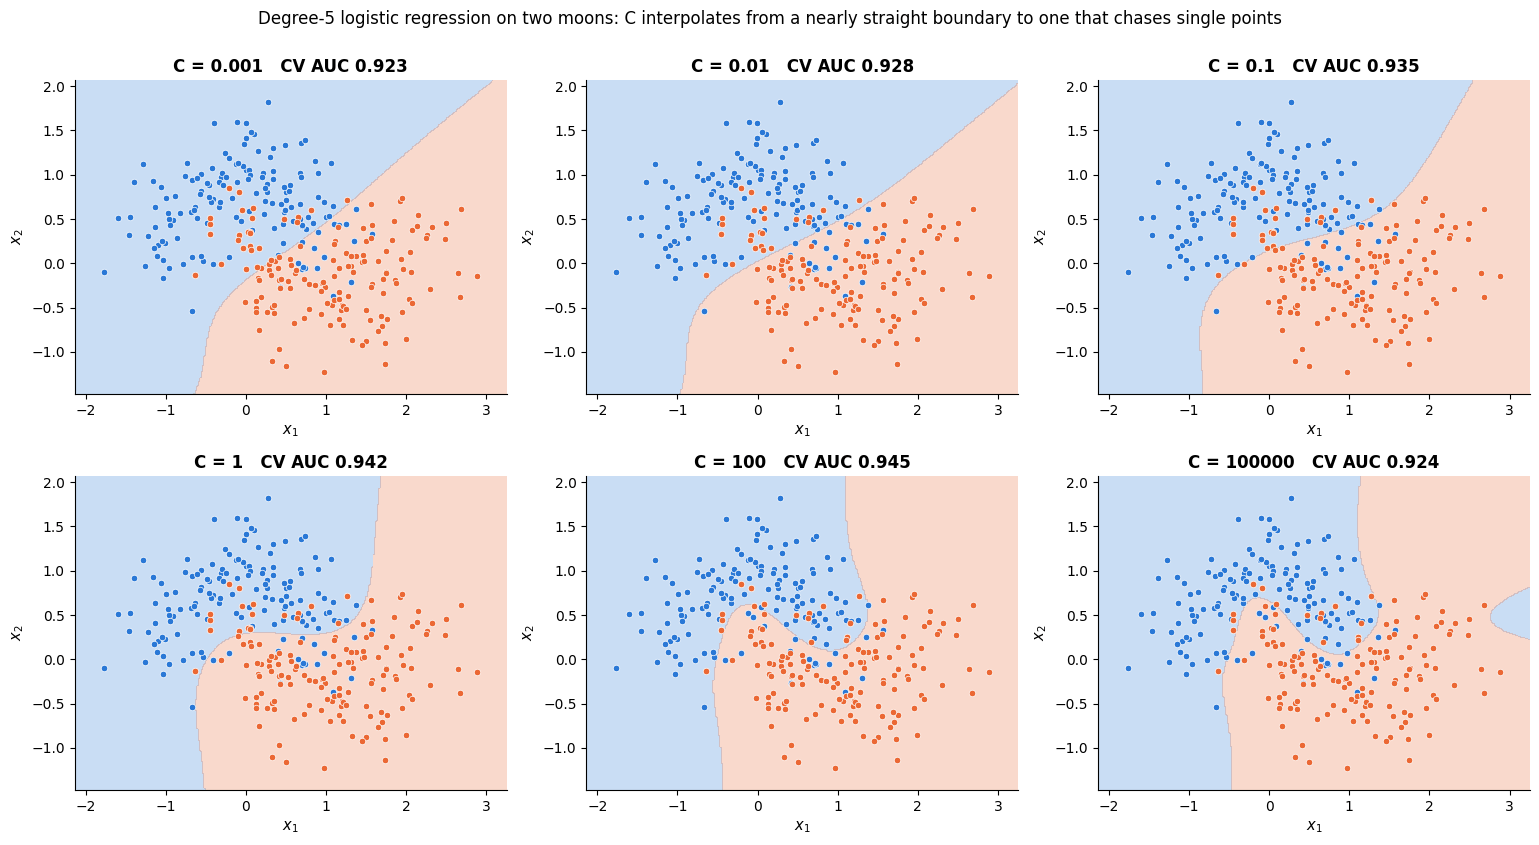

In [32]:
from sklearn.datasets import make_moons

X_wig, y_wig = make_moons(n_samples=300, noise=0.32, random_state=RANDOM_STATE)
Cs_show = [0.001, 0.01, 0.1, 1.0, 100.0, 100000.0]
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.4))
for ax, C in zip(axes.ravel(), Cs_show):
    model = make_pipeline(PolynomialFeatures(5), StandardScaler(),
                          LogisticRegression(C=C, max_iter=10000)).fit(X_wig, y_wig)
    cv_auc = cross_val_score(model, X_wig, y_wig, cv=cv5, scoring="roc_auc").mean()
    plot_decision_boundary(model, X_wig, y_wig, ax=ax, feature_names=("$x_1$", "$x_2$"),
                           title=f"C = {C:g}   CV AUC {cv_auc:.3f}")
    ax.legend().remove()
fig.suptitle("Degree-5 logistic regression on two moons: C interpolates from a nearly straight "
             "boundary to one that chases single points", y=1.0)
plt.tight_layout()
plt.show()

At `C = 0.001` the penalty has crushed the high-order terms and the boundary is almost
straight — it cuts through both moons. In the middle of the range it bends into the gap
between them. At `C = 10^5` it grows fingers and islands around individual noisy points, and
the cross-validated AUC — highest in the middle of the range — falls back at both ends.
That is the bias–variance trade-off of notebook 5, drawn.

### 10.4 `class_weight`

`class_weight` is not a capacity knob, so judge it with metrics that see the minority class.
On the imbalanced data of section 8, balanced weighting transforms the *threshold-dependent*
metrics and leaves the *ranking* metric almost untouched.

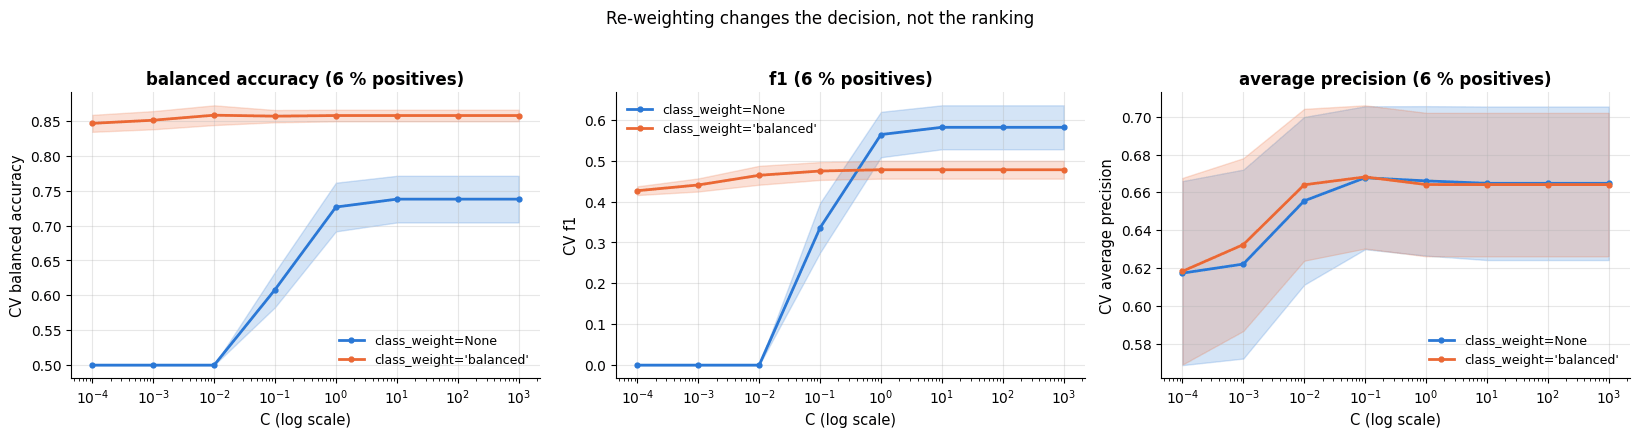

In [33]:
Cs_cw = np.logspace(-4, 3, 8)                          # a coarser grid: eight fits per curve is enough
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.2))
for metric, ax in zip(["balanced_accuracy", "f1", "average_precision"], axes):
    for weight, colour in [(None, PALETTE[0]), ("balanced", PALETTE[1])]:
        res = np.array([cv_mean_se(LogisticRegression(C=C, class_weight=weight, max_iter=5000),
                                   X=X_imb, y=y_imb, scoring=metric) for C in Cs_cw])
        ax.plot(Cs_cw, res[:, 0], "-o", ms=3.5, color=colour, label=f"class_weight={weight!r}")
        ax.fill_between(Cs_cw, res[:, 0] - res[:, 1], res[:, 0] + res[:, 1], alpha=0.2, color=colour)
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_ylabel(f"CV {metric.replace('_', ' ')}")
    ax.set_title(f"{metric.replace('_', ' ')} (6 % positives)")
    ax.legend(fontsize=9)
fig.suptitle("Re-weighting changes the decision, not the ranking", y=1.03)
plt.tight_layout()
plt.show()

Read the three panels together. Balanced accuracy jumps from 0.74 to 0.86 — the model now
predicts the minority class at all. $F_1$ moves the *other* way, because the extra recall is
bought with false positives. Average precision, which is computed from the scores and is
therefore blind to where the threshold sits, hardly moves at all. That is the cleanest
evidence that `class_weight` and the threshold are two handles on the same lever: if you
only need a different operating point, move the threshold and keep your calibrated
probabilities.

### 10.5 The solver: same answer, different bill

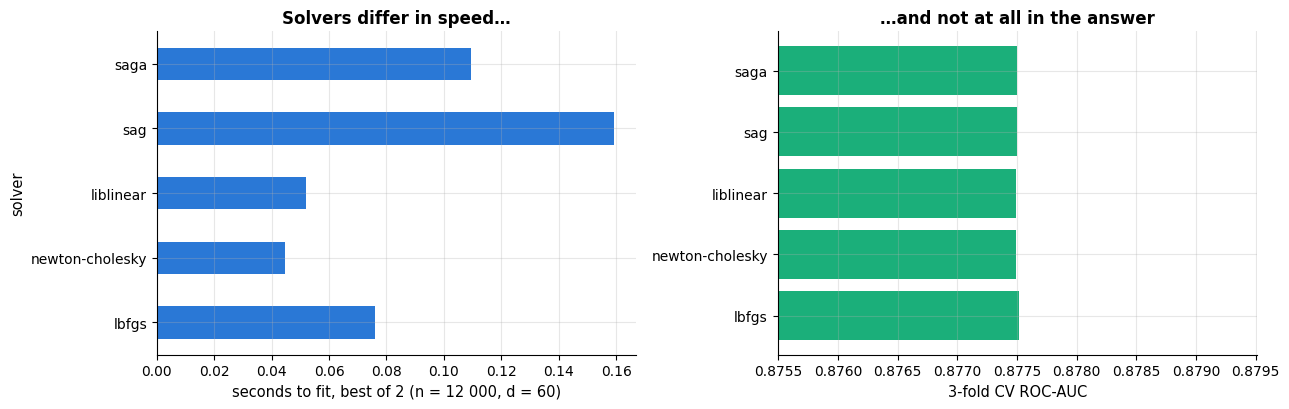

,fit time (s),CV ROC-AUC
solver,,
lbfgs,0.0761,0.8775
newton-cholesky,0.0447,0.8775
liblinear,0.0521,0.8775
sag,0.1591,0.8775
saga,0.1094,0.8775


In [34]:
import time

X_big, y_big = make_classification(n_samples=12000, n_features=60, n_informative=20,
                                   random_state=RANDOM_STATE)
X_big = StandardScaler().fit_transform(X_big)
solver_rows = []
for solver in ["lbfgs", "newton-cholesky", "liblinear", "sag", "saga"]:
    model = LogisticRegression(solver=solver, C=1.0, max_iter=5000, random_state=RANDOM_STATE)
    times = []
    for _ in range(2):                                    # best of 2: timings on a shared CPU are noisy
        t0 = time.perf_counter()
        model.fit(X_big, y_big)
        times.append(time.perf_counter() - t0)
    solver_rows.append({"solver": solver, "fit time (s)": min(times),
                        "CV ROC-AUC": cross_val_score(model, X_big, y_big, cv=3, scoring="roc_auc").mean()})
solver_df = pd.DataFrame(solver_rows).set_index("solver")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
solver_df["fit time (s)"].plot.barh(ax=axes[0], color=PALETTE[0])
axes[0].set_xlabel("seconds to fit, best of 2 (n = 12 000, d = 60)")
axes[0].set_title("Solvers differ in speed…")
axes[1].barh(solver_df.index, solver_df["CV ROC-AUC"], color=PALETTE[2])
axes[1].set_xlim(solver_df["CV ROC-AUC"].min() - 0.002, solver_df["CV ROC-AUC"].max() + 0.002)
axes[1].set_xlabel("3-fold CV ROC-AUC")
axes[1].set_title("…and not at all in the answer")
plt.tight_layout()
plt.show()
solver_df.round(4)

All five solvers agree on the cross-validated AUC to four decimal places — they minimise the
same convex function — while the fit times do not agree at all, and the spread is easily
large enough to matter when a hyper-parameter search fits hundreds of models. Which one wins
depends on the shape of the problem, not on the solver being "better": `newton-cholesky`
pays $O(nd^2)$ per step to form the Hessian, so it wins when $d$ is small and $n$ huge and
loses as $d$ grows; `saga` pays little per step but needs many of them; `liblinear` is
built for small sparse problems. Use the compatibility table in §3.3 to narrow the choice,
then measure on *your* data. (Timings on a shared two-core machine are noisy — hence
best-of-two.)

### 10.6 The threshold, tuned by cross-validation

The threshold deserves the same treatment as any other hyper-parameter: a curve with error
bars, computed on data the model has not seen.

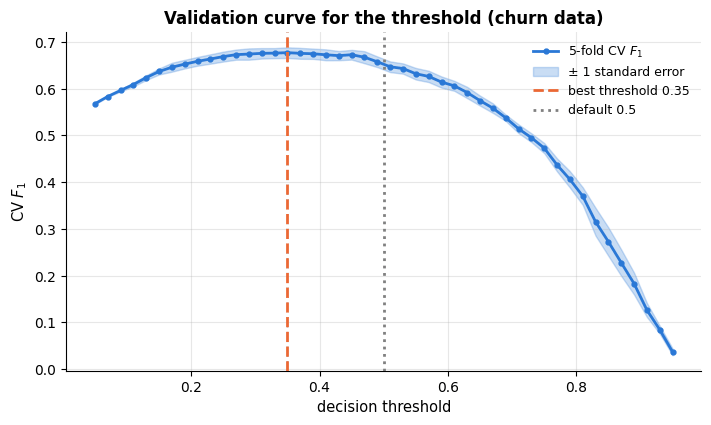

In [35]:
thr_grid = np.linspace(0.05, 0.95, 46)
fold_scores = np.zeros((cv5.get_n_splits(), len(thr_grid)))
for k, (tr_idx, va_idx) in enumerate(cv5.split(X_ch_tr, y_ch_tr)):
    fold_model = Pipeline([("prep", preprocess), ("lr", LogisticRegression(max_iter=2000,
                                                                          random_state=RANDOM_STATE))])
    fold_model.fit(X_ch_tr.iloc[tr_idx], y_ch_tr[tr_idx])
    p_va = fold_model.predict_proba(X_ch_tr.iloc[va_idx])[:, 1]
    for j, t in enumerate(thr_grid):
        fold_scores[k, j] = f1_score(y_ch_tr[va_idx], (p_va >= t).astype(int), zero_division=0)
mean_thr = fold_scores.mean(axis=0)
se_thr = fold_scores.std(axis=0, ddof=1) / np.sqrt(fold_scores.shape[0])

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(thr_grid, mean_thr, "-o", ms=3.5, color=PALETTE[0], label="5-fold CV $F_1$")
ax.fill_between(thr_grid, mean_thr - se_thr, mean_thr + se_thr, alpha=0.25, color=PALETTE[0],
                label="± 1 standard error")
ax.axvline(thr_grid[int(np.argmax(mean_thr))], color=PALETTE[1], ls="--",
           label=f"best threshold {thr_grid[int(np.argmax(mean_thr))]:.2f}")
ax.axvline(0.5, color="gray", ls=":", label="default 0.5")
ax.set_xlabel("decision threshold")
ax.set_ylabel("CV $F_1$")
ax.set_title("Validation curve for the threshold (churn data)")
ax.legend(fontsize=9)
plt.show()

### 10.7 Practical notes

- **The best value sits at the edge of the grid** → extend the grid. If the best `C` is the
  largest you tried, your data may be separable (section 9.2) or the penalty may simply be
  unhelpful; if it is the smallest, the signal is weak and the model is being told to
  predict the prior.
- **The curve is flat** → apply the **one-standard-error rule** (Breiman et al., 1984): take
  the simplest model (smallest `C`) whose CV score is within one SE of the best. The plateau
  of the `C` curve above spans four orders of magnitude and the standard-error band is wider
  than the whole plateau; picking the peak is noise chasing.
- **Runtime.** `C` is free to tune (each fit is independent and fast); `l1_ratio` forces
  `saga`, which is several times slower; the threshold is essentially free because it needs
  no refitting — tune it with `TunedThresholdClassifierCV` or on stored CV predictions.
- **Not worth tuning:** `tol`, `intercept_scaling`, `fit_intercept`, `warm_start`, and the
  solver itself (beyond the compatibility table in §3.3). Spend the budget on features
  instead — for a linear model, feature engineering is where the wins are (notebook 4).
- Use `LogisticRegressionCV` for a quick built-in `C` search, or `GridSearchCV` when the
  search space also contains preprocessing choices (notebook 12).

## 11. Case study: breast cancer diagnosis

### 11.1 The data and the question

The **breast cancer Wisconsin** data (Street, Wolberg & Mangasarian, 1993) is real: 569
fine-needle aspirates of breast masses, 30 features computed from digitised images of the
cell nuclei (mean, standard error and worst value of ten shape and texture measurements),
and a biopsy-confirmed label — malignant or benign.

The clinical question is not "what fraction of cases do we get right?" but *"how many
malignancies do we miss?"*. A missed malignancy delays treatment; a false alarm costs an
additional biopsy, which is unpleasant and expensive but not dangerous. We therefore encode
**malignant = 1** (scikit-learn ships the opposite convention, which is a classic source of
sign errors) and will optimise recall on that class at an acceptable precision.

In [36]:
X_bc_all = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_bc_all = (cancer.target == 0).astype(int)                 # 1 = malignant (sklearn's 0), 0 = benign
Xbc_tr, Xbc_te, ybc_tr, ybc_te = train_test_split(X_bc_all, y_bc_all, test_size=0.25,
                                                  stratify=y_bc_all, random_state=RANDOM_STATE)
print(f"{len(y_bc_all)} biopsies, {y_bc_all.mean():.1%} malignant")
print(f"train {len(ybc_tr)} (malignant {ybc_tr.mean():.1%}) | test {len(ybc_te)} (malignant {ybc_te.mean():.1%})")
X_bc_all.iloc[:, :6].describe().loc[["mean", "std", "min", "max"]].round(2)

569 biopsies, 37.3% malignant
train 426 (malignant 37.3%) | test 143 (malignant 37.1%)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
mean,14.13,19.29,91.97,654.89,0.10,0.10
std,3.52,4.30,24.30,351.91,0.01,0.05
min,6.98,9.71,43.79,143.50,0.05,0.02
max,28.11,39.28,188.50,2501.00,0.16,0.35


The feature scales differ by three orders of magnitude (`mean area` ~ 650 vs `mean smoothness`
~ 0.1), so standardisation inside the pipeline is mandatory before a penalised fit.

### 11.2 Baselines and a first model

In [37]:
bc_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
# a scorer with zero_division=0: the majority-class dummy never predicts "malignant", so precision is undefined
scoring = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy", "recall": "recall",
           "precision": make_scorer(precision_score, zero_division=0),
           "roc_auc": "roc_auc", "average_precision": "average_precision"}
baseline_rows = []
for name, model in [("DummyClassifier(prior)", DummyClassifier(strategy="most_frequent")),
                    ("logistic regression (C=1)", bc_pipe)]:
    res = cross_validate(model, Xbc_tr, ybc_tr, cv=cv5, scoring=scoring)
    baseline_rows.append({"model": name, **{s: res[f"test_{s}"].mean() for s in scoring}})
pd.DataFrame(baseline_rows).set_index("model").round(3)

,accuracy,balanced_accuracy,recall,precision,roc_auc,average_precision
model,,,,,,
DummyClassifier(prior),0.627,0.500,0.000,0.000,0.500,0.373
logistic regression (C=1),0.972,0.966,0.944,0.981,0.991,0.991


### 11.3 Tuning with the guide from section 10

`C` first, scored by **average precision** (we care about the malignant class and the data
are moderately imbalanced), then the penalty.

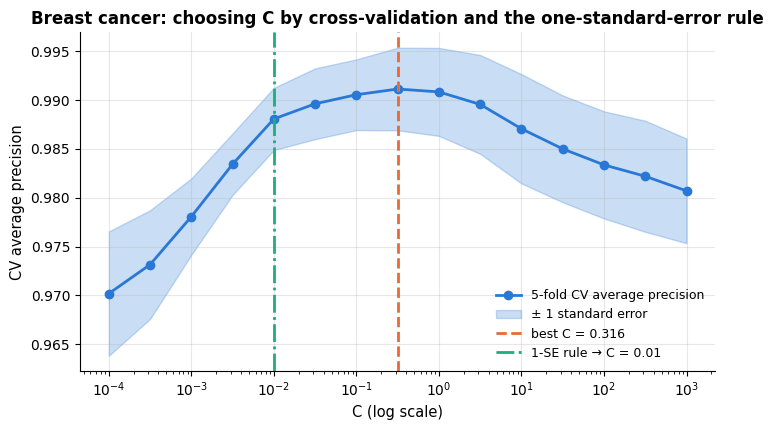

l1_ratio=0.0  CV AP = 0.9881 ± 0.0032   non-zero coefficients: 30/30
l1_ratio=0.5  CV AP = 0.9788 ± 0.0039   non-zero coefficients: 11/30
l1_ratio=1.0  CV AP = 0.9753 ± 0.0044   non-zero coefficients: 3/30


In [38]:
bc_curve = np.array([cv_mean_se(make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=5000)),
                                X=Xbc_tr, y=ybc_tr, scoring="average_precision") for C in Cs_tune])
best_bc = int(np.argmax(bc_curve[:, 0]))
one_se_bc = bc_curve[best_bc, 0] - bc_curve[best_bc, 1]
C_bc = float(Cs_tune[np.flatnonzero(bc_curve[:, 0] >= one_se_bc)[0]])

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.plot(Cs_tune, bc_curve[:, 0], "-o", color=PALETTE[0], label="5-fold CV average precision")
ax.fill_between(Cs_tune, bc_curve[:, 0] - bc_curve[:, 1], bc_curve[:, 0] + bc_curve[:, 1],
                alpha=0.25, color=PALETTE[0], label="± 1 standard error")
ax.axvline(Cs_tune[best_bc], color=PALETTE[1], ls="--", label=f"best C = {Cs_tune[best_bc]:.3g}")
ax.axvline(C_bc, color=PALETTE[2], ls="-.", label=f"1-SE rule → C = {C_bc:.3g}")
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("CV average precision")
ax.set_title("Breast cancer: choosing C by cross-validation and the one-standard-error rule")
ax.legend(fontsize=9, loc="lower right")
plt.show()

for ratio in [0.0, 0.5, 1.0]:
    m = make_pipeline(StandardScaler(), LogisticRegression(C=C_bc, l1_ratio=ratio, solver="saga",
                                                           max_iter=8000, random_state=RANDOM_STATE))
    mean, se = cv_mean_se(m, X=Xbc_tr, y=ybc_tr, scoring="average_precision")
    n_kept = np.sum(np.abs(m.fit(Xbc_tr, ybc_tr)[-1].coef_[0]) > 1e-6)
    print(f"l1_ratio={ratio:<4} CV AP = {mean:.4f} ± {se:.4f}   non-zero coefficients: {n_kept}/30")

The $\ell_2$ model scores highest, but the $\ell_1$ model gives up only about one point of
average precision while keeping a *tenth* of the 30 features — a gap of roughly two standard
errors. That is the trade worth discussing with a clinician: three measurements are easier to
collect, to audit and to explain than thirty correlated ones. We keep the $\ell_2$ model here because the full
feature set costs nothing to measure (all 30 come from the same image) and its probabilities
are the ones we will use for the cost calculation.

### 11.4 Honest evaluation on the untouched test set

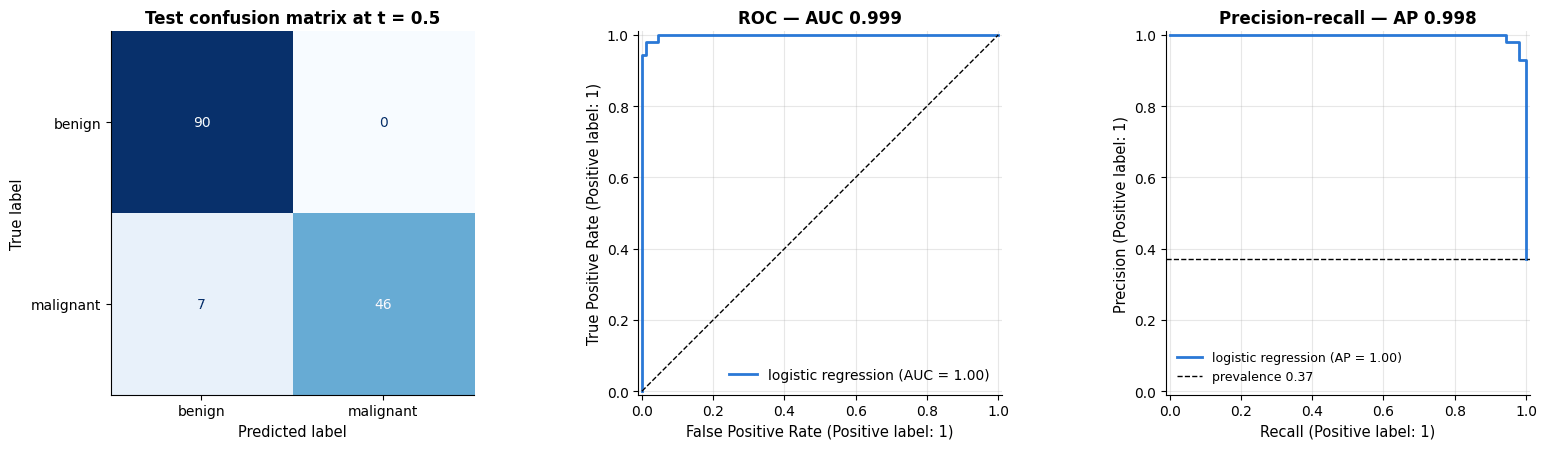

              precision    recall  f1-score   support

      benign      0.928     1.000     0.963        90
   malignant      1.000     0.868     0.929        53

    accuracy                          0.951       143
   macro avg      0.964     0.934     0.946       143
weighted avg      0.955     0.951     0.950       143

sensitivity 0.868, specificity 1.000  ->  LR+ = inf, LR- = 0.132
A positive prediction multiplies the pre-test odds of malignancy by LR+; a negative one by LR-.


In [39]:
bc_final = make_pipeline(StandardScaler(),
                         LogisticRegression(C=C_bc, max_iter=5000, random_state=RANDOM_STATE)).fit(Xbc_tr, ybc_tr)
proba_bc = bc_final.predict_proba(Xbc_te)[:, 1]
pred_bc = bc_final.predict(Xbc_te)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
ConfusionMatrixDisplay(confusion_matrix(ybc_te, pred_bc), display_labels=["benign", "malignant"]).plot(
    cmap="Blues", ax=axes[0], colorbar=False, values_format="d")
axes[0].set_title("Test confusion matrix at t = 0.5")
axes[0].grid(False)
RocCurveDisplay.from_predictions(ybc_te, proba_bc, ax=axes[1], name="logistic regression",
                                 curve_kwargs={"color": PALETTE[0]})
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title(f"ROC — AUC {roc_auc_score(ybc_te, proba_bc):.3f}")
PrecisionRecallDisplay.from_predictions(ybc_te, proba_bc, ax=axes[2], color=PALETTE[0], name="logistic regression")
axes[2].axhline(ybc_te.mean(), color="black", ls="--", lw=1, label=f"prevalence {ybc_te.mean():.2f}")
axes[2].set_title(f"Precision–recall — AP {average_precision_score(ybc_te, proba_bc):.3f}")
axes[2].legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()
print(classification_report(ybc_te, pred_bc, target_names=["benign", "malignant"], digits=3))
tn_b, fp_b, fn_b, tp_b = confusion_matrix(ybc_te, pred_bc, labels=[0, 1]).ravel()
sens_b, spec_b = tp_b / (tp_b + fn_b), tn_b / (tn_b + fp_b)
lr_p = np.inf if fp_b == 0 else sens_b / (1 - spec_b)          # LR+ is infinite when there are no false positives
lr_n = (1 - sens_b) / spec_b
print(f"sensitivity {sens_b:.3f}, specificity {spec_b:.3f}  ->  LR+ = {lr_p:.1f}, LR- = {lr_n:.3f}")
print("A positive prediction multiplies the pre-test odds of malignancy by LR+; a negative one by LR-.")

### 11.5 Choosing the operating point from the cost of a miss

Let a missed malignancy cost ten times an unnecessary biopsy — a conservative statement of
standard screening practice. The optimal threshold for a calibrated model is then
$1/(1+10) \approx 0.09$. We *choose* it by cross-validation on the training data with
`TunedThresholdClassifierCV` and only then look at the test set.

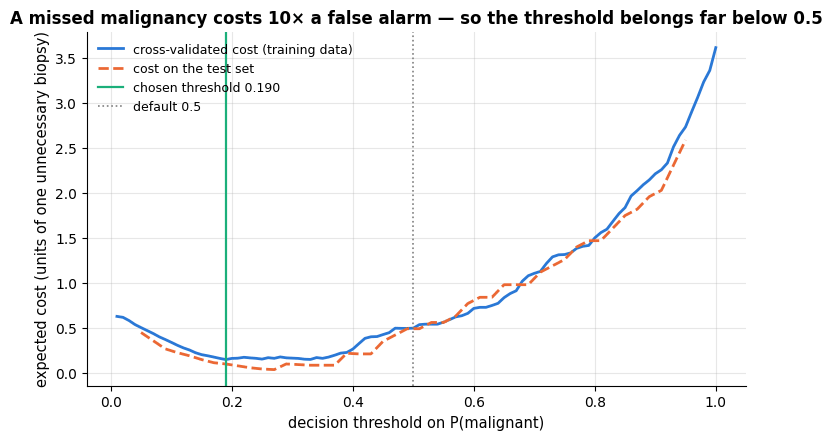

theoretical optimum for a calibrated model: 1/(1 + 10) = 0.091
chosen by 5-fold CV on the training data  : 0.190


,missed malignancies (FN),false alarms (FP),recall,precision,expected cost
operating point,,,,,
default t = 0.5,7,0,0.868,1.000,0.490
cost-tuned t = 0.190,0,14,1.000,0.791,0.098


In [40]:
COST_RATIO = 10.0

def clinical_cost(y_true, y_pred):
    _, fp_, fn_, _ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return (COST_RATIO * fn_ + 1.0 * fp_) / len(y_true)     # in units of "one unnecessary biopsy"

bc_tuned = TunedThresholdClassifierCV(
    bc_final, scoring=make_scorer(clinical_cost, greater_is_better=False, response_method="predict"),
    cv=5, thresholds=100, store_cv_results=True, random_state=RANDOM_STATE).fit(Xbc_tr, ybc_tr)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(bc_tuned.cv_results_["thresholds"], -bc_tuned.cv_results_["scores"], lw=2, color=PALETTE[0],
        label="cross-validated cost (training data)")
ax.plot(thr_grid, [clinical_cost(ybc_te, (proba_bc >= t).astype(int)) for t in thr_grid],
        lw=2, ls="--", color=PALETTE[1], label="cost on the test set")
ax.axvline(bc_tuned.best_threshold_, color=PALETTE[2], lw=1.6, label=f"chosen threshold {bc_tuned.best_threshold_:.3f}")
ax.axvline(0.5, color="gray", ls=":", lw=1.2, label="default 0.5")
ax.set_xlabel("decision threshold on P(malignant)")
ax.set_ylabel("expected cost (units of one unnecessary biopsy)")
ax.set_title("A missed malignancy costs 10× a false alarm — so the threshold belongs far below 0.5")
ax.legend(fontsize=9)
plt.show()
print(f"theoretical optimum for a calibrated model: 1/(1 + {COST_RATIO:.0f}) = {1 / (1 + COST_RATIO):.3f}")
print(f"chosen by 5-fold CV on the training data  : {bc_tuned.best_threshold_:.3f}")

rows_ops = []
for label, pred in [("default t = 0.5", pred_bc), (f"cost-tuned t = {bc_tuned.best_threshold_:.3f}",
                                                   bc_tuned.predict(Xbc_te))]:
    tn_o, fp_o, fn_o, tp_o = confusion_matrix(ybc_te, pred, labels=[0, 1]).ravel()
    rows_ops.append({"operating point": label, "missed malignancies (FN)": fn_o, "false alarms (FP)": fp_o,
                     "recall": recall_score(ybc_te, pred), "precision": precision_score(ybc_te, pred),
                     "expected cost": clinical_cost(ybc_te, pred)})
pd.DataFrame(rows_ops).set_index("operating point").round(3)

Cross-validation lands above the theoretical $1/(1+10) \approx 0.09$. Two reasons, and both
are worth knowing. The cost curve has a flat bottom, so anywhere in that valley the cost is
practically the same and the CV estimate has room to wobble. But there is also a systematic
reason, which §11.6 makes visible: the formula assumes **calibrated** probabilities, and this
heavily regularised model's probabilities are shrunk towards the base rate — so the threshold
that behaves like "0.09" on a calibrated model sits higher on this one. What matters here is
the *size* of the move — from 0.5 down into the low tenths — and its effect: the missed
malignancies disappear at the price of a few extra biopsies.

### 11.6 Are the probabilities trustworthy?

Section 7 claimed that maximum-likelihood logistic regression is calibrated by construction.
That claim has a condition attached — *unpenalised* maximum likelihood — and we have just
deployed a heavily penalised model. Let us check, against the same model fitted at the
CV-best `C` and against a Platt-recalibrated version of the deployed one.

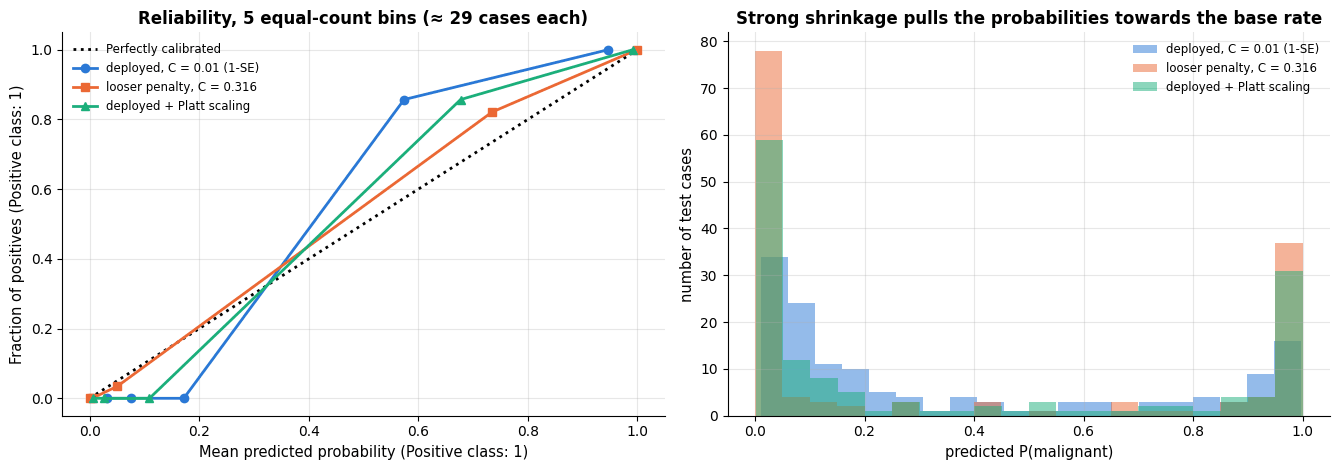

,Brier,log loss,ROC-AUC,share of |p−0.5| > 0.45
model,,,,
"deployed, C = 0.01 (1-SE)",0.0416,0.1729,0.9987,0.2937
"looser penalty, C = 0.316",0.0188,0.0731,0.9977,0.8042
deployed + Platt scaling,0.0259,0.1057,0.9985,0.6294


In [41]:
bc_looser = make_pipeline(StandardScaler(),
                          LogisticRegression(C=float(Cs_tune[best_bc]), max_iter=5000,
                                             random_state=RANDOM_STATE)).fit(Xbc_tr, ybc_tr)
bc_recal = CalibratedClassifierCV(make_pipeline(StandardScaler(),
                                                LogisticRegression(C=C_bc, max_iter=5000,
                                                                   random_state=RANDOM_STATE)),
                                  method="sigmoid", cv=5).fit(Xbc_tr, ybc_tr)
variants = [(f"deployed, C = {C_bc:.3g} (1-SE)", proba_bc, PALETTE[0], "o"),
            (f"looser penalty, C = {Cs_tune[best_bc]:.3g}", bc_looser.predict_proba(Xbc_te)[:, 1], PALETTE[1], "s"),
            (f"deployed + Platt scaling", bc_recal.predict_proba(Xbc_te)[:, 1], PALETTE[2], "^")]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
cal_rows = []
for name, p_hat, colour, marker in variants:
    CalibrationDisplay.from_predictions(ybc_te, p_hat, n_bins=5, strategy="quantile", ax=axes[0],
                                        name=name, color=colour, marker=marker)
    axes[1].hist(p_hat, bins=20, alpha=0.5, color=colour, label=name)
    cal_rows.append({"model": name, "Brier": brier_score_loss(ybc_te, p_hat),
                     "log loss": log_loss(ybc_te, p_hat), "ROC-AUC": roc_auc_score(ybc_te, p_hat),
                     "share of |p−0.5| > 0.45": np.mean((p_hat < 0.05) | (p_hat > 0.95))})
axes[0].set_title("Reliability, 5 equal-count bins (≈ 29 cases each)")
axes[0].legend(loc="upper left", fontsize=8.5)
axes[1].set_xlabel("predicted P(malignant)")
axes[1].set_ylabel("number of test cases")
axes[1].set_title("Strong shrinkage pulls the probabilities towards the base rate")
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.show()
pd.DataFrame(cal_rows).set_index("model").round(4)

The deployed model is **under-confident**: its reliability curve sits above the diagonal in
the upper bins (it says "42 % malignant" for a group that is almost all malignant), and its
probability histogram is squeezed into the middle instead of piling up at 0 and 1. That is
the penalty at work — shrinking $\mathbf{w}$ shrinks every log-odds towards zero, and
$\sigma$ maps them towards the base rate. The ranking is untouched (the AUC is the highest of
the three), which is exactly why the one-standard-error rule, scored on *average precision*,
was happy to choose it.

Two fixes, both shown above: loosen the penalty, or keep the model and recalibrate it. Both
cut the Brier score and the log loss substantially — the looser penalty by more than half —
while leaving the AUC essentially alone. And this is the resolution of the puzzle at the end of
§11.5: a compressed probability scale is precisely why the cost-optimal threshold came out at
0.19 rather than the textbook 0.09.

> **Key idea.** Selecting a model by a *ranking* metric (AUC, average precision) tells you
> nothing about whether its probabilities are usable as numbers. If a downstream decision
> multiplies the probability by a cost, check calibration explicitly and either tune against
> a proper scoring rule (`scoring="neg_log_loss"` or `"neg_brier_score"`) or recalibrate.

### 11.7 What the model says: odds ratios

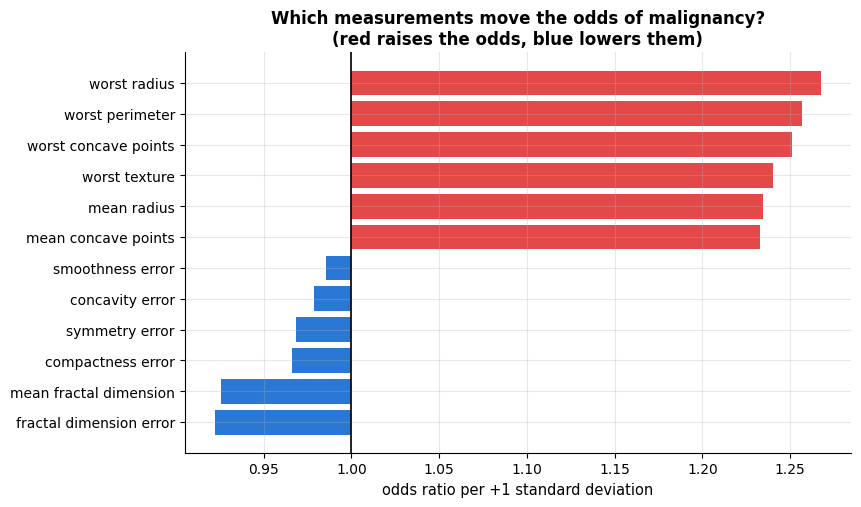

largest positive effects (odds ratio per +1 SD):
  worst radius               x1.27
  worst perimeter            x1.26
  worst concave points       x1.25
  worst texture              x1.24
largest protective effects:
  fractal dimension error    x0.92
  mean fractal dimension     x0.93


In [42]:
coefs_bc = pd.Series(bc_final[-1].coef_[0], index=X_bc_all.columns).sort_values()
top = pd.concat([coefs_bc.head(6), coefs_bc.tail(6)])
fig, ax = plt.subplots(figsize=(8.6, 5.2))
colours = [PALETTE[0] if v < 0 else PALETTE[7] for v in top.to_numpy()]
ax.barh(top.index, np.exp(top.to_numpy()) - 1.0, left=1.0, color=colours)
ax.axvline(1.0, color="black", lw=1.2)
ax.set_xlabel("odds ratio per +1 standard deviation")
ax.set_title("Which measurements move the odds of malignancy?\n(red raises the odds, blue lowers them)")
plt.show()
print("largest positive effects (odds ratio per +1 SD):")
for name_f, value in coefs_bc.tail(4).iloc[::-1].items():
    print(f"  {name_f:26s} x{np.exp(value):.2f}")
print("largest protective effects:")
for name_f, value in coefs_bc.head(2).items():
    print(f"  {name_f:26s} x{np.exp(value):.2f}")

Because the features were standardised, each bar is the multiplicative effect of a
one-standard-deviation increase, and the bars are comparable to one another. The features
with the largest positive effect are the "worst" (largest-nucleus) size and shape
measurements — radius, perimeter, concave points — which is exactly the criterion a
pathologist would name. The individual odds ratios look modest because the one-standard-error
rule chose a *strongly* regularised model that spreads the signal across all 30 highly
correlated features; the ensemble of small effects is what produces the 0.999 test AUC.
That is also the usual caveat from notebook 6, §4.2: with collinear features the individual
coefficients are unstable even when the predictions are not, so use permutation importance
(notebook 17) when you need a defensible ranking.

### 11.8 What to tell a non-technical stakeholder

> On 143 held-out biopsies, the model ranks malignant cases above benign ones almost
> perfectly (ROC-AUC 0.999). At the default threshold it misses 7 of the 53 malignancies and
> raises no false alarms; at the threshold chosen for a 10:1 cost of a miss over a false
> alarm it misses **none** of them, at the price of 14 benign cases sent for a biopsy they
> did not need. That is the trade-off to put in front of the clinical team — it is a choice
> about costs, not about the model. The model is a weighted score of 30 image measurements,
> and the weights are inspectable: the largest nucleus size and irregularity measurements
> drive the score, which matches clinical practice. **It is a triage aid, not a diagnosis**:
> it was fitted on 426 cases from one institution, its error bars at this sample size are
> wide, and it must be revalidated on the local population and monitored for drift
> (notebook 18) before it goes anywhere near a patient. The fairness questions — does it
> perform equally well across age groups and imaging devices? — are addressed in notebook 19.

## Summary

- Logistic regression models the **log-odds** as a linear function; $\sigma$ converts the
  score to a probability, and the decision boundary is a hyperplane.
- The **cross-entropy loss** comes from the Bernoulli likelihood. Its gradient is
  $\frac1n\mathbf{X}^\top(\mathbf{p}-\mathbf{y})$ and its Hessian
  $\frac1n\mathbf{X}^\top\mathbf{S}\mathbf{X} \succeq 0$: the problem is **convex**, so
  gradient descent, Newton/IRLS and scikit-learn all find the same optimum.
- **Always regularise** (`C`, `l1_ratio`) and always standardise first; on separable data
  the unpenalised MLE does not exist.
- For $K>2$ classes, the **softmax** model generalises everything; it is the default and is
  usually preferable to one-vs-rest.
- Every classification metric is a function of the **confusion matrix**. Accuracy is the
  wrong default under imbalance; use balanced accuracy, $F_\beta$, MCC or average precision,
  and read `classification_report` per class.
- **ROC-AUC** is $P(\text{score}^+ > \text{score}^-)$: a ranking measure, blind to
  calibration and to prevalence. **Average precision** is the right summary when the
  positives are rare.
- The **threshold is a decision, not a constant**: derive it from a cost matrix and tune it
  with `TunedThresholdClassifierCV` on cross-validated predictions.
- **Calibration** is what makes probabilities actionable; check it with a reliability
  diagram, summarise with Brier/log loss, and repair it with Platt scaling or isotonic
  regression.

| Situation | Reach for |
|---|---|
| Baseline classifier, need probabilities | `LogisticRegression` in a `StandardScaler` pipeline |
| Many irrelevant features | `l1_ratio=1` (or elastic net) with `solver="saga"`, `C` tuned jointly |
| Imbalanced classes | `class_weight="balanced"`, average precision / MCC, tuned threshold |
| Errors cost different amounts | cost matrix → `TunedThresholdClassifierCV` |
| Probabilities used as numbers | reliability diagram, Brier score, `CalibratedClassifierCV` |
| Multi-class report | `classification_report`, macro-$F_1$, normalised confusion matrix |
| Non-linear boundary | feature expansion, or notebooks 9–11 |

**Next steps:** notebook 8 compares logistic regression with naive Bayes as a
generative–discriminative pair; notebook 9 (decision trees) and notebook 10 (ensembles)
supply the non-linear alternatives and reuse every metric defined here; notebook 11 replaces
the logistic loss with the hinge loss; notebook 12 automates the hyper-parameter search;
notebook 17 revisits coefficient interpretation with permutation importance and SHAP; and
notebook 19 asks whether a threshold that is optimal on average is fair to everyone.

## Exercises

### Exercise 1 — $F_1$ from the confusion matrix (easy)
Write a function `f_beta(cm, beta)` that takes a $2\times2$ confusion matrix in scikit-learn's
layout and returns $F_\beta$. Check it against `fbeta_score` for $\beta \in \{0.5, 1, 2\}$ on
the churn predictions. Which value of $\beta$ would you choose for a cancer screening test,
and why?

<details><summary>Solution sketch</summary>

```py
def f_beta(cm, beta):
    tn, fp, fn, tp = cm.ravel()
    p, r = tp / (tp + fp), tp / (tp + fn)
    return (1 + beta**2) * p * r / (beta**2 * p + r)
```
For screening choose $\beta > 1$ (e.g. 2): a missed cancer is much worse than a recall
appointment, so recall should dominate. Note that $F_\beta$ ignores $TN$ entirely — which is
why MCC is often the better single number.
</details>

### Exercise 2 — ROC by hand (easy)
Implement `roc_by_hand(y_true, scores)` that sorts the scores in decreasing order, sweeps the
threshold through every unique value, and returns the arrays of FPR and TPR. Plot it on top
of `RocCurveDisplay` for the churn model and check that the curves coincide and that the
trapezoidal area matches `roc_auc_score`.

<details><summary>Solution sketch</summary>

Sort by score descending; the cumulative sums of `y_true` and `1 - y_true` give TP and FP at
each cut; divide by the totals. `np.trapezoid(tpr, fpr)` reproduces `roc_auc_score` to
machine precision. Remember to prepend the point $(0,0)$.
</details>

### Exercise 3 — A cost matrix of your own (medium)
For the churn model, suppose the retention offer costs €40 but only works 60 % of the time,
so the expected saving from a correctly identified churner is $0.6 \times 300 - 40$. Write
the corresponding cost function, find the optimal threshold with
`TunedThresholdClassifierCV`, and compare the expected cost per customer with the default
threshold. How does the optimum move if the campaign's success rate drops to 30 %?

<details><summary>Solution sketch</summary>

The cost of a true positive is no longer zero: $\text{cost} = c_{FN}FN + c_{FP}FP + c_{TP}TP$
with $c_{TP} = 40 - 0.6\cdot300 = -140$ (a gain). Encode it with `make_scorer(...,
greater_is_better=False)` and let `TunedThresholdClassifierCV` search. A lower success rate
raises the effective cost of acting, so the optimal threshold rises towards 0.5.
</details>

### Exercise 4 — Calibrating a $k$-nearest-neighbours classifier (medium)
Fit `KNeighborsClassifier(n_neighbors=5)` on the churn training data (inside the pipeline)
and draw its reliability diagram. Why are its probabilities quantised to multiples of 0.2?
Calibrate it with both `method="sigmoid"` and `method="isotonic"` and compare log loss,
Brier score and ROC-AUC.

<details><summary>Solution sketch</summary>

With $k=5$ only six distinct probabilities can ever be produced (0/5, 1/5, …, 5/5), so the
reliability diagram has at most six points. Isotonic regression fits this staircase well and
usually wins on Brier; the AUC hardly changes because both maps are monotone. Increasing $k$
(notebook 8) is the other way to get a finer probability grid.
</details>

### Exercise 5 — Multinomial versus one-vs-rest on digits (medium)
Compare `LogisticRegression` (multinomial) with `OneVsRestClassifier(LogisticRegression())`
on the digits data: accuracy, macro-$F_1$, log loss and fit time, with `C` tuned by 5-fold CV
for each. Where do the two disagree most — inspect the confusion matrices.

<details><summary>Solution sketch</summary>

Accuracy is usually within a fraction of a point; the multinomial model has the clearly
better log loss because its probabilities are normalised jointly rather than rescaled after
the fact. OvR disagreements concentrate on digits that are "second choice" for several binary
classifiers at once (4/9, 3/8).
</details>

### Exercise 6 — Separation in the wild (hard)
Take the breast cancer data and keep only the five features with the largest absolute
standardised coefficients. Fit `LogisticRegression(C=np.inf)` (no penalty) on the *training*
split and inspect $\|\mathbf{w}\|$ and `n_iter_`. Then add a single mislabelled point and
refit. Explain what changed, and show that the penalised fit is insensitive to it.

<details><summary>Solution sketch</summary>

On the reduced feature set the training data are (nearly) separable, so the unpenalised fit
runs to `max_iter` with a large $\|\mathbf{w}\|$ and probabilities pinned at 0 and 1. One
mislabelled point destroys separation: the MLE becomes finite and $\|\mathbf{w}\|$ drops by
an order of magnitude — a spectacular instability. With `C=1` the coefficient norm barely
moves in either case. This is the practical argument for always keeping a penalty.
</details>

## References and further reading

### Textbooks

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — Chapter 4 covers logistic regression and classification at exactly this level.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — §4.4 derives logistic regression and IRLS; §9.2 the ROC analysis.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. — §4.3 is the cleanest derivation of the logistic and softmax models and their Newton–Raphson fit.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — Chapter 10 (logistic regression) and chapter 5 (decision theory: how costs pick the threshold).
- Agresti, A. (2013). *Categorical Data Analysis* (3rd ed.). Wiley. — The statistician's reference on odds ratios, deviance and inference for binary regression.
- Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley. — Model building, diagnostics and interpretation in the applied sciences.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapter 3 is a practical tour of classification metrics.

### Papers

- Cox, D. R. (1958). The regression analysis of binary sequences. *Journal of the Royal Statistical Society: Series B*, 20(2), 215–242. — The paper that introduced logistic regression as we use it.
- Albert, A., & Anderson, J. A. (1984). On the existence of maximum likelihood estimates in logistic regression models. *Biometrika*, 71(1), 1–10. — The separation problem demonstrated in §9.2.
- Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861–874. — The standard reference on ROC curves, AUC and its interpretation.
- Davis, J., & Goadrich, M. (2006). The relationship between precision-recall and ROC curves. *Proceedings of ICML 2006*, 233–240. — Proves the dominance relation between the two curves.
- Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLoS ONE*, 10(3), e0118432. — The experiment of §6.4, at scale.
- Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427–437. — A taxonomy of what each metric is invariant to.
- Chicco, D., & Jurman, G. (2020). The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy in binary classification evaluation. *BMC Genomics*, 21, 6. — The argument for MCC as the default single number.
- Platt, J. C. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. In *Advances in Large Margin Classifiers*, MIT Press, 61–74. — Platt scaling.
- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *Proceedings of ICML 2005*, 625–632. — Which model families are calibrated, and which are not; isotonic vs. sigmoid.
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. *Proceedings of ICML 2017*. — Shows that bigger models are often *worse* calibrated; temperature scaling.
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357. — The resampling option of §8.
- Brier, G. W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review*, 78(1), 1–3. — The Brier score.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of SPIE 1905*, 861–870. — The case-study data.
- Pedregosa, F., et al. (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

### Documentation and online resources

- scikit-learn user guide, *Logistic regression* — https://scikit-learn.org/stable/modules/linear_model.html
- scikit-learn user guide, *Metrics and scoring: quantifying the quality of predictions* — https://scikit-learn.org/stable/modules/model_evaluation.html — the definitive list of every metric and scorer name.
- scikit-learn user guide, *Tuning the decision threshold for class prediction* — https://scikit-learn.org/stable/modules/classification_threshold.html
- scikit-learn user guide, *Probability calibration* — https://scikit-learn.org/stable/modules/calibration.html
- Google, *Rules of Machine Learning* — https://developers.google.com/machine-learning/guides/rules-of-ml — rules 1–10 argue for exactly the kind of simple, well-understood baseline this notebook builds.